# Composite cross-sections & shadow figures

Cloud-root composite cross-sections (L&P style) and windowed circulation + SW% anomaly figures.

Extracted from `base_comparison.ipynb`.


In [2]:
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path

# ── path setup ────────────────────────────────────────────────────────────────
_HERE = Path.cwd()                                   # analysis/
sys.path.insert(0, str(_HERE))                       # cass_analysis, catalog
sys.path.insert(0, str(_HERE / 'cloud_roots'))       # cloud_root_composite_average

from cass_analysis import (
    plot_cloud_root_composite, COMPOSITE_VARS,
    plot_circulation_composite,
    load_sfc_sw_dn,
)
from cloud_root_composite_average import average_reps, average_reps_windowed
from sw_surface_composite import (
    WINDOWS as SZA_WINDOWS, WINDOW_LABELS as SZA_LABELS,
    solar_angles,
)
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec


In [3]:
# ── experiment ────────────────────────────────────────────────────────────────
SCRATCH        = '/pscratch/sd/m/mpowell/CASS_LES'
EXPT_KEY       = 'no_aerosols_zero_wind'
EXPT_REL       = f'experiments/{EXPT_KEY}'
N_REPS         = 4

# ── cloud-root composite config ───────────────────────────────────────────────
COMPOSITE_ROOT = f'{SCRATCH}/analysis/cloud_root_composite'

# ── output ────────────────────────────────────────────────────────────────────
SAVE_PDF = False

# ── CASES ─────────────────────────────────────────────────────────────────────
CASES = [
    dict(
        key       = '1D',
        label     = '1D (2stream)',
        run_root  = f'{SCRATCH}/{EXPT_REL}/2stream',
        comp_expt = EXPT_KEY,
        comp_rt   = '2stream',
        color     = 'C0',
    ),
    dict(
        key       = '3D',
        label     = '3D (raytracer)',
        run_root  = f'{SCRATCH}/{EXPT_REL}/raytracer',
        comp_expt = EXPT_KEY,
        comp_rt   = 'raytracer',
        color     = 'C1',
    ),
]

print('Config loaded.')


Config loaded.


## 4. L&P composite cross-sections

Cloud objects with chord ≥ 1 km, 11:30–17:00 LST.  
Requires composite event files — built by `cloud_roots/free_vs_nudge_cloud_roots.ipynb` Sections A–B.


In [4]:
# ── Load composite data (both xz and yz) ─────────────────────────────────────
comp_data = {}
print('Loading composites …')
for case in CASES:
    print(f'  {case["label"]}:')
    result = average_reps(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        n_reps=N_REPS, verbose=True,
    )
    comp_data[case['key']] = result   # dict with 'xz' and/or 'yz' keys

_avail = {
    orient: {k: comp_data[k][orient] for k in comp_data if orient in comp_data[k]}
    for orient in ('xz', 'yz')
}
for orient, cases in _avail.items():
    print(f'  {orient}: {list(cases.keys())} available')

# ── Windowed composites (equal-zenith-angle bands) ───────────────────────────
from cloud_root_composite_average import average_reps_windowed
from sw_surface_composite import WINDOWS as SZA_WINDOWS, WINDOW_LABELS as SZA_LABELS

print(f'\nLoading windowed composites ({len(SZA_WINDOWS)} equal-θ_z bands) …')
for i, (w, l) in enumerate(zip(SZA_WINDOWS, SZA_LABELS)):
    print(f'  Window {i}: LST {w[0]:.2f}–{w[1]:.2f}  |  {l}')

comp_windowed = {}   # comp_windowed[case_key][wi] = {'xz': ds, 'yz': ds, 'label': str}
for case in CASES:
    print(f'\n  {case["label"]}:')
    comp_windowed[case['key']] = average_reps_windowed(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        windows=SZA_WINDOWS, window_labels=SZA_LABELS,
        n_reps=N_REPS, verbose=True,
    )

print('\nWindowed composites loaded.')


Loading composites …
  1D (2stream):


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  xz  rep_01: 180 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  xz  rep_02: 149 events


...

/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:187: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)


  yz  rep_03  win 0 (11:30–14:12  (θ_z 17–33°)): 45 events
  yz  rep_03  win 1 (14:12–15:37  (θ_z 33–50°)): 103 events
  yz  rep_03  win 2 (15:37–17:00  (θ_z 50–67°)): 38 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:187: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)


  yz  rep_04  win 0 (11:30–14:12  (θ_z 17–33°)): 51 events
  yz  rep_04  win 1 (14:12–15:37  (θ_z 33–50°)): 89 events
  yz  rep_04  win 2 (15:37–17:00  (θ_z 50–67°)): 36 events

Windowed composites loaded.


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:210: RuntimeWarning: Mean of empty slice
  np.nanmean(stack, axis=0), dims=["z_nd", "xL"])
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [5]:
# ── Load sw_composite cache (built by cloud_roots/sw_surface_composite.py) ────
# NOTE: sw_composite.nc must be regenerated with the new 3 equal-zenith windows
# before this cell will produce correct results.
# Toggle LWP overlay on the Q panels
SHOW_LWP_ON_Q = True

_SW_WIN_COLORS = ['#4292c6', '#fd8d3c', '#8B0000']  # blue→orange→red, near-zenith→high-zenith

sw_data = {}   # sw_data[key] = dict with Q_xz, Q_yz, LWP_xz, LWP_yz, solar_zen, win_labels, Q_domain_mean

for case in CASES:
    rt  = case['comp_rt']
    key = case['key']

    Q_xz_reps, Q_yz_reps     = [], []
    LWP_xz_reps, LWP_yz_reps = [], []
    Q_dm_reps = []
    solar_zen = None
    win_labels = None

    for i in range(1, N_REPS + 1):
        nc = (Path(COMPOSITE_ROOT) / EXPT_KEY / rt
              / f'rep_{i:02d}' / 'sw_composite.nc')
        if not nc.exists():
            print(f'  MISSING sw_composite: {nc}')
            continue
        ds_sw = xr.open_dataset(nc)
        n_win_file = ds_sw.sizes.get('window', 4)
        if solar_zen is None:
            solar_zen  = ds_sw['solar_zen_deg'].values
            win_labels = eval(ds_sw.attrs.get('window_labels', str(SZA_LABELS)))
        for arr_list, var in [
            (Q_xz_reps,   'Q_mean_xz'),
            (Q_yz_reps,   'Q_mean_yz'),
            (LWP_xz_reps, 'LWP_mean_xz'),
            (LWP_yz_reps, 'LWP_mean_yz'),
        ]:
            if var in ds_sw:
                arr_list.append(ds_sw[var].values)
        if 'Q_domain_mean' in ds_sw:
            Q_dm_reps.append(ds_sw['Q_domain_mean'].values)
        ds_sw.close()

    def _ens(reps):
        if not reps:
            return None
        stk = np.stack(reps)
        return np.nanmean(stk, axis=0)

    sw_data[key] = dict(
        Q_xz=_ens(Q_xz_reps),     Q_yz=_ens(Q_yz_reps),
        LWP_xz=_ens(LWP_xz_reps), LWP_yz=_ens(LWP_yz_reps),
        Q_domain_mean=_ens(Q_dm_reps),   # (n_win,) ensemble-mean domain-mean SW↓
        solar_zen=solar_zen,
        win_labels=win_labels,
        n_reps=len(Q_xz_reps),
    )
    print(f'{key} ({rt}): {len(Q_xz_reps)} rep(s) loaded, {n_win_file} windows')
    if _ens(Q_dm_reps) is not None:
        print(f'  Q_domain_mean = {_ens(Q_dm_reps)}')

print('sw_data ready.')


1D (2stream): 4 rep(s) loaded, 3 windows
  Q_domain_mean = [931.6552 865.7667 707.3311]
3D (raytracer): 4 rep(s) loaded, 3 windows
  Q_domain_mean = [944.2425  876.76807 709.6685 ]
sw_data ready.


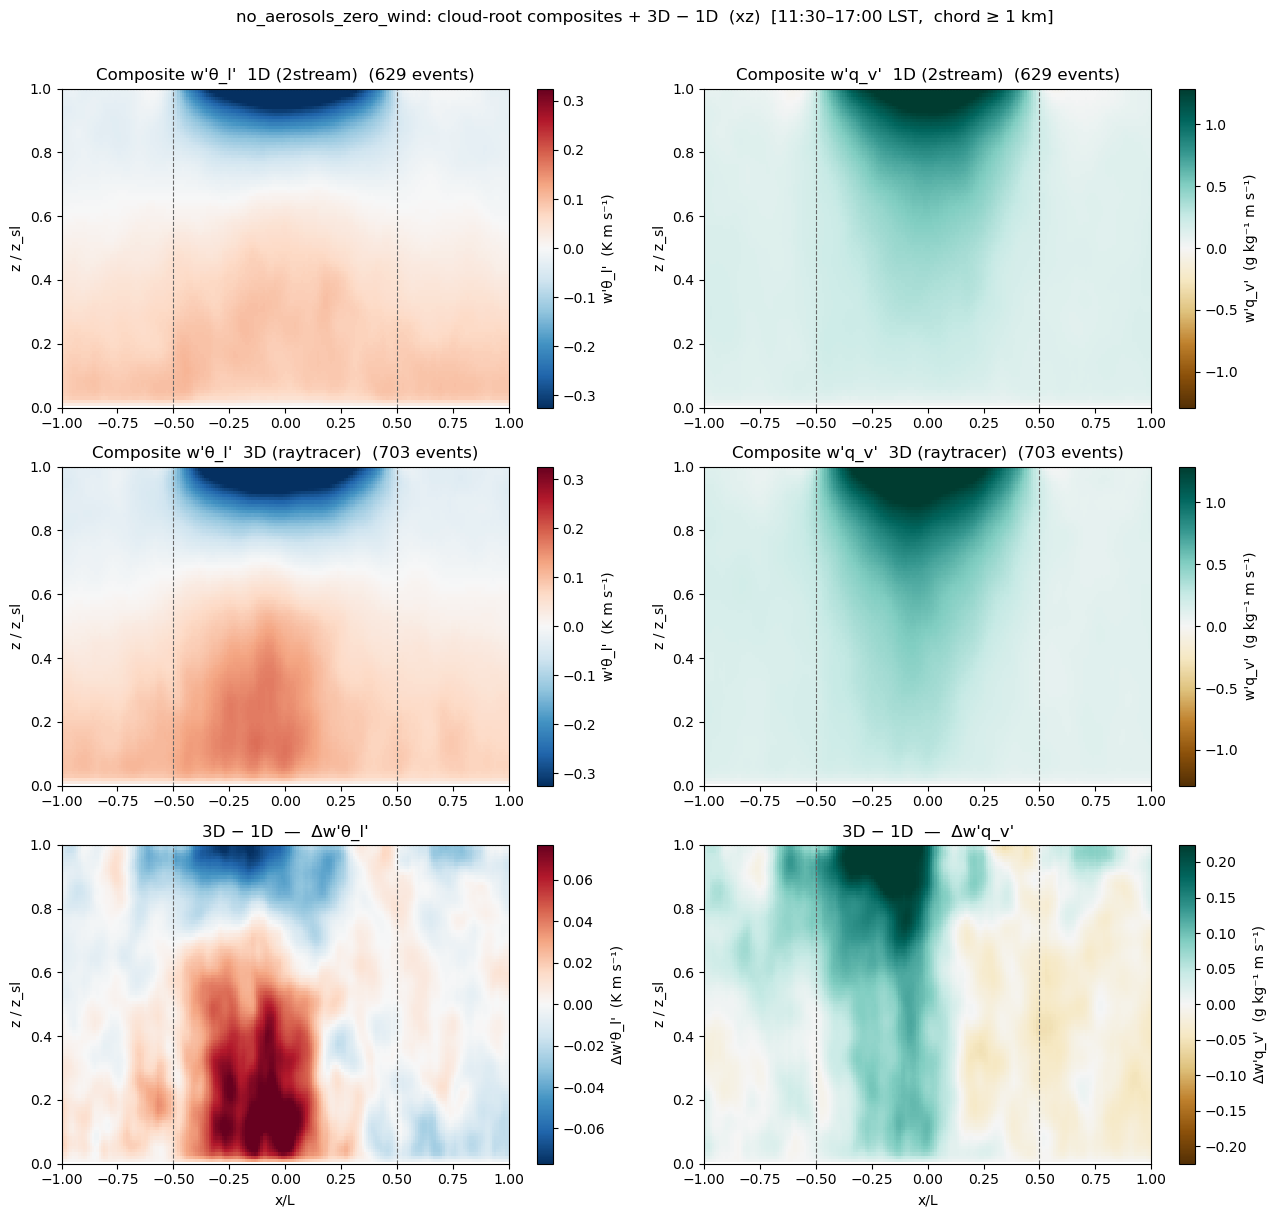

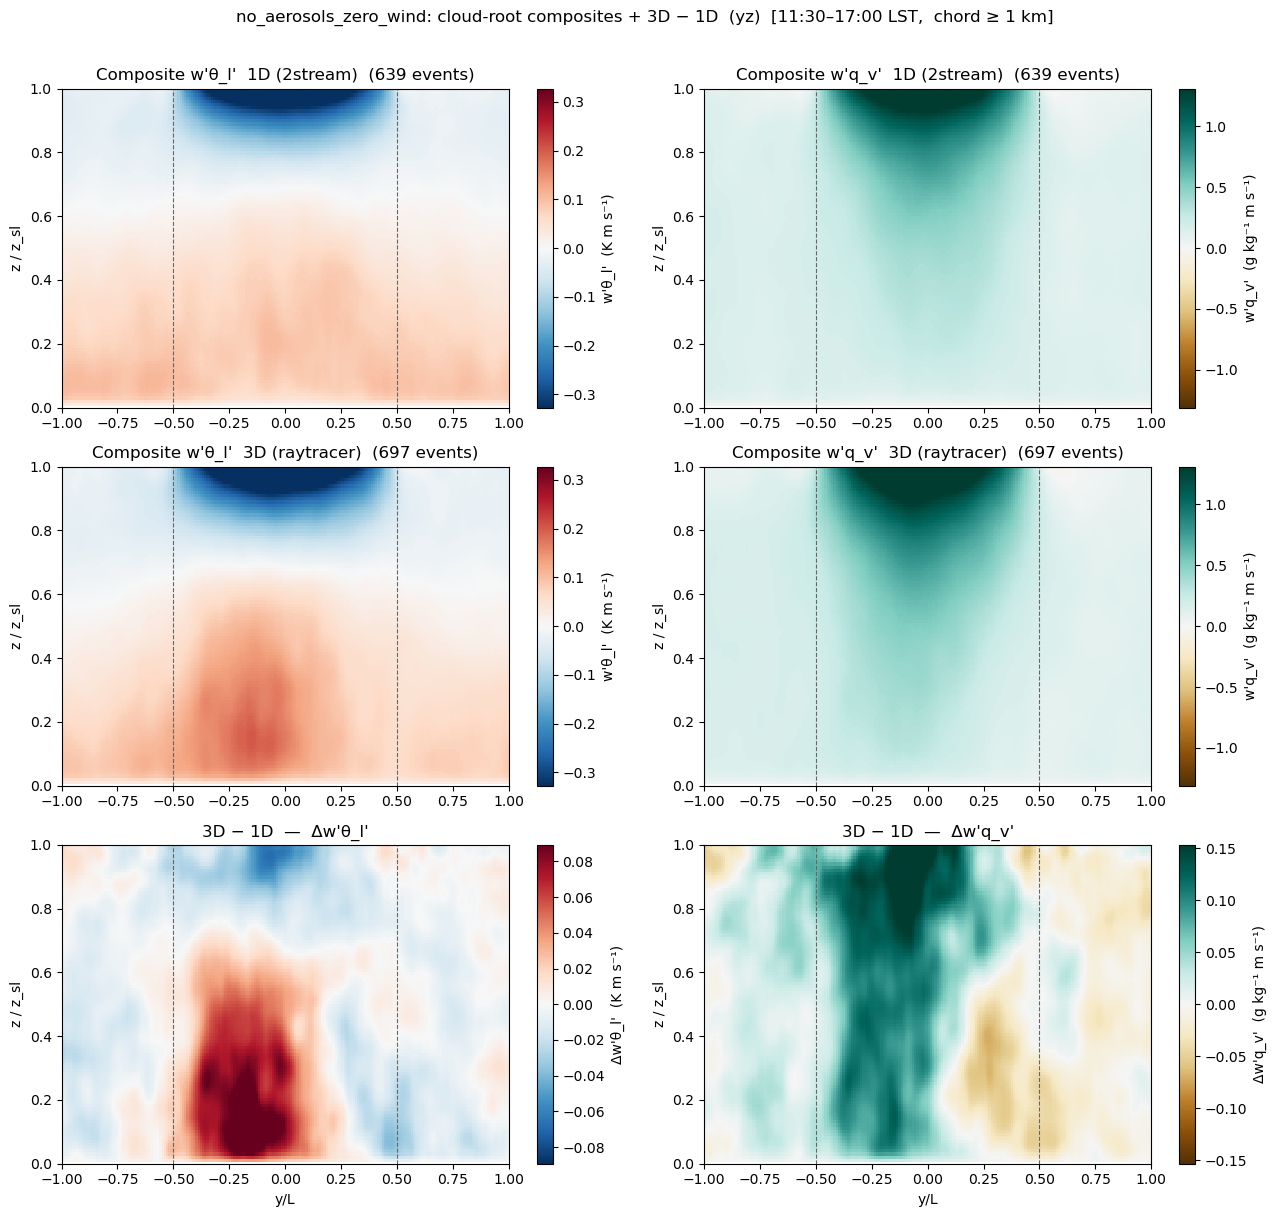

In [6]:
def _plot_composite_figure(avail_orient, orient):
    """Draw composite figure for one orientation (xz or yz).

    Rows: 1D, 3D, then 3D−1D diff (if both available).
    Only the bottom row gets an x/L or y/L label.
    """
    if not avail_orient:
        print(f'No {orient} composite data — skipping.')
        return

    def _collect(vn):
        return np.concatenate([ds[vn].values.ravel() for ds in avail_orient.values()])

    vmax_thl = float(np.nanpercentile(np.abs(_collect('w_thl_mean')), 98))
    vmax_qv  = float(np.nanpercentile(np.abs(_collect('w_qv_mean')),  98))
    vlim_thl = (-vmax_thl, vmax_thl)
    vlim_qv  = (-vmax_qv,  vmax_qv)

    _plot_rows = [c for c in CASES if c['key'] in avail_orient]
    _has_diff  = '1D' in avail_orient and '3D' in avail_orient
    n_rows     = len(_plot_rows) + (1 if _has_diff else 0)

    fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, case in enumerate(_plot_rows):
        is_bottom = (row == n_rows - 1)
        plot_cloud_root_composite(
            axes[row, 0], axes[row, 1],
            avail_orient[case['key']],
            vlim_thl=vlim_thl, vlim_qv=vlim_qv,
            label=case['label'],
            show_xlabel=is_bottom,
            orient=orient,
        )

    if _has_diff:
        row   = len(_plot_rows)   # always the bottom row
        ds_3d = avail_orient['3D']
        ds_1d = avail_orient['1D']
        xL    = ds_3d.xL.values
        z_nd  = ds_3d.z_nd.values
        hl    = 'x/L' if orient == 'xz' else 'y/L'

        for col, (var, cmap, clabel) in enumerate([
            ('w_thl_mean', 'RdBu_r', "Δw'θ_l'  (K m s⁻¹)"),
            ('w_qv_mean',  'BrBG',   "Δw'q_v'  (g kg⁻¹ m s⁻¹)"),
        ]):
            ax   = axes[row, col]
            diff = ds_3d[var].values - ds_1d[var].values
            vmax = float(np.nanpercentile(np.abs(diff), 98))
            pcm  = ax.pcolormesh(xL, z_nd, diff, cmap=cmap, shading='auto',
                                  vmin=-vmax, vmax=vmax)
            plt.colorbar(pcm, ax=ax, label=clabel)
            ax.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax.axvline( 0.5, color='0.4', lw=0.8, ls='--')
            ax.axhline( 1.0, color='0.4', lw=0.8, ls=':')
            ax.set_xlabel(hl)          # always shown — this IS the bottom row
            ax.set_ylabel('z / z_sl')
            ax.set_xlim(-1, 1)
            ax.set_ylim(0, 1.0)
            ax.set_title(f"3D − 1D  —  {clabel.split('(')[0].strip()}")

    plt.suptitle(
        f'{EXPT_KEY}: cloud-root composites + 3D − 1D  ({orient})  '
        '[11:30–17:00 LST,  chord ≥ 1 km]',
        y=1.01,
    )
    plt.tight_layout()
    if SAVE_PDF:
        fname = f'composites_baseline_{orient}.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'Saved {fname}')
    plt.show()


_plot_composite_figure(_avail['xz'], 'xz')
_plot_composite_figure(_avail['yz'], 'yz')

In [ ]:
_XL = np.linspace(-1.0, 1.0, 200)   # matches XL_GRID in cass_analysis.py


def _plot_diff_circulation(ax, ds_3d, ds_1d, vlim_b, orient='xz',
                           show_xlabel=True, quiver_stride=(10, 5),
                           quiver_scale=None):
    """Plot 3D − 1D difference for b', horiz_wind', w'.  Returns pcm."""
    xL   = ds_3d.xL.values
    z_nd = ds_3d.z_nd.values

    b_diff = ds_3d['b_prime_mean'].values - ds_1d['b_prime_mean'].values
    u_diff = (ds_3d['horiz_wind_prime_mean'].values
              - ds_1d['horiz_wind_prime_mean'].values)
    w_diff = ds_3d['w_prime_mean'].values - ds_1d['w_prime_mean'].values

    pcm = ax.pcolormesh(xL, z_nd, b_diff, cmap='RdBu_r', shading='auto',
                        vmin=vlim_b[0], vmax=vlim_b[1])

    sx, sz = quiver_stride
    xi = np.arange(0, len(xL), sx)
    zi = np.arange(0, len(z_nd), sz)
    Xq, Zq = np.meshgrid(xL[xi], z_nd[zi])
    Uq = u_diff[np.ix_(zi, xi)]
    Wq = w_diff[np.ix_(zi, xi)]

    qkw = dict(pivot='mid', color='k', linewidth=0.4, alpha=0.75)
    if quiver_scale is not None:
        qkw['scale'] = quiver_scale
    ax.quiver(Xq, Zq, Uq, Wq, **qkw)

    xlabel = 'x/L' if orient == 'xz' else 'y/L'
    wind_label = "u'" if orient == 'xz' else "v'"
    ax.axvline(-0.5, color='0.4', lw=0.8, ls='--')
    ax.axvline( 0.5, color='0.4', lw=0.8, ls='--')
    ax.axhline( 1.0, color='0.4', lw=0.8, ls=':')
    if show_xlabel:
        ax.set_xlabel(xlabel)
    ax.set_ylabel('z / z_sl')
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1.0)

    # Event counts
    def _nev(ds):
        if 'n_events_per_rep' in ds:
            return int(ds['n_events_per_rep'].values.sum())
        return '?'
    n1, n3 = _nev(ds_1d), _nev(ds_3d)
    ax.set_title(f"3D − 1D  Δb' + (Δ{wind_label}, Δw')  ({n3}−{n1} events)")
    return pcm


def _compute_global_limits(comp_windowed, orientations=('xz', 'yz')):
    """Precompute shared vlim_b and quiver_scale across ALL windows and orientations."""
    n_win = len(SZA_WINDOWS)
    all_b   = []
    all_mag = []
    for orient in orientations:
        for wi in range(n_win):
            for case_key in ('1D', '3D'):
                ds = comp_windowed.get(case_key, {}).get(wi, {}).get(orient)
                if ds is None or 'b_prime_mean' not in ds:
                    continue
                all_b.append(ds['b_prime_mean'].values.ravel())
                u = ds['horiz_wind_prime_mean'].values
                w = ds['w_prime_mean'].values
                all_mag.append(np.sqrt(u**2 + w**2).ravel())

            # Also include diff fields
            ds_1d = comp_windowed.get('1D', {}).get(wi, {}).get(orient)
            ds_3d = comp_windowed.get('3D', {}).get(wi, {}).get(orient)
            if (ds_1d is not None and ds_3d is not None
                    and 'b_prime_mean' in ds_1d and 'b_prime_mean' in ds_3d):
                b_diff = ds_3d['b_prime_mean'].values - ds_1d['b_prime_mean'].values
                all_b.append(b_diff.ravel())
                u_d = ds_3d['horiz_wind_prime_mean'].values - ds_1d['horiz_wind_prime_mean'].values
                w_d = ds_3d['w_prime_mean'].values - ds_1d['w_prime_mean'].values
                all_mag.append(np.sqrt(u_d**2 + w_d**2).ravel())

    all_b   = np.concatenate(all_b)
    all_mag = np.concatenate(all_mag)
    vmax_b  = float(np.nanpercentile(np.abs(all_b[np.isfinite(all_b)]), 98))
    mag98   = float(np.nanpercentile(all_mag[np.isfinite(all_mag)], 98))
    return (-vmax_b, vmax_b), mag98 * 10


def _plot_shadow_figure_windowed(orient, vlim_b=None, shared_qscale=None):
    """One figure per zenith-angle window: 1D, 3D, diff, SW% anomaly.

    Uses comp_windowed (per-window composites) and sw_data.
    All panels share a single colorbar and vector scale.
    The SW panel shows percent deviation from domain-mean SW↓.
    """
    n_win = len(SZA_WINDOWS)
    has_both = '1D' in comp_windowed and '3D' in comp_windowed
    Q_key   = f'Q_{orient}'
    LWP_key = f'LWP_{orient}'
    hl      = 'x/L' if orient == 'xz' else 'y/L'

    for wi in range(n_win):
        win_label = SZA_LABELS[wi]

        # Gather per-window datasets for this orientation
        ds_1d = comp_windowed.get('1D', {}).get(wi, {}).get(orient)
        ds_3d = comp_windowed.get('3D', {}).get(wi, {}).get(orient)

        avail_panels = []
        if ds_1d is not None and 'b_prime_mean' in ds_1d:
            avail_panels.append(('1D', ds_1d))
        if ds_3d is not None and 'b_prime_mean' in ds_3d:
            avail_panels.append(('3D', ds_3d))

        if not avail_panels:
            print(f'Window {wi} ({win_label}): no {orient} data — skipping.')
            continue

        has_diff = has_both and ds_1d is not None and ds_3d is not None \
                   and 'b_prime_mean' in ds_1d and 'b_prime_mean' in ds_3d

        # ── Figure layout ────────────────────────────────────────────────
        n_circ = len(avail_panels) + (1 if has_diff else 0)  # 1D, 3D, diff
        n_rows = n_circ + 1   # + SW% panel
        h_ratios = [4] * n_circ + [1]
        fig = plt.figure(figsize=(8, 4.5 * n_circ + 2))

        # Use GridSpec with a thin column for shared colorbar
        gs = fig.add_gridspec(n_rows, 2, width_ratios=[1, 0.03],
                              height_ratios=h_ratios, hspace=0.12, wspace=0.04)

        ax_circ = []
        for r in range(n_circ):
            ax = fig.add_subplot(gs[r, 0])
            ax_circ.append(ax)
            ax.tick_params(labelbottom=False)

        ax_sw = fig.add_subplot(gs[n_circ, 0], sharex=ax_circ[0])

        # ── Circulation panels (1D, 3D) ─────────────────────────────────
        case_labels = {'1D': '1D', '3D': '3D'}
        pcm = None
        for row, (key, ds) in enumerate(avail_panels):
            pcm = plot_circulation_composite(
                ax_circ[row], ds,
                vlim_b=vlim_b,
                label=case_labels.get(key, key),
                show_xlabel=False,
                orient=orient,
                show_colorbar=False,
                quiver_scale=shared_qscale,
            )

        # ── Difference panel ─────────────────────────────────────────────
        if has_diff:
            diff_row = len(avail_panels)
            pcm_diff = _plot_diff_circulation(
                ax_circ[diff_row], ds_3d, ds_1d,
                vlim_b=vlim_b, orient=orient,
                show_xlabel=False,
                quiver_scale=shared_qscale,
            )


        # cbar_ax = fig.add_subplot(gs[:n_circ, 1])
        # fig.colorbar(pcm, cax=cbar_ax, label="b'  (m s⁻²)")

        # ── SW % anomaly panel ───────────────────────────────────────────
        ax_sw.axhline(0, color='0.6', lw=0.5, ls='--')
        ax_sw.axvline(-0.5, color='0.4', lw=0.8, ls='--')
        ax_sw.axvline( 0.5, color='0.4', lw=0.8, ls='--')

        sw_plotted = False
        for key, ds in avail_panels:
            sd    = sw_data.get(key, {})
            Q_arr = sd.get(Q_key)      # (n_win, 200) or None
            sol_z = sd.get('solar_zen')

            if Q_arr is not None and wi < Q_arr.shape[0]:
                Q_win = Q_arr[wi]
                Q_dm  = sd.get('Q_domain_mean')
                if not np.all(np.isnan(Q_win)):
                    # Use true domain-mean SW↓ as reference (not profile mean)
                    if Q_dm is not None and wi < len(Q_dm) and Q_dm[wi] > 0:
                        Q_ref = Q_dm[wi]
                    else:
                        Q_ref = np.nanmean(Q_win)  # fallback
                    Q_pct = 100.0 * (Q_win - Q_ref) / Q_ref
                    color = CASES[0]['color'] if key == '1D' else CASES[1]['color']

                    ax_sw.plot(_XL, Q_pct, color=color, lw=1.8,
                              label=f'{case_labels.get(key, key)}')
                    sw_plotted = True

        cbar_ax = fig.add_subplot(gs[:n_circ, 3])
        fig.colorbar(pcm, cax=cbar_ax, label="b'  (m s⁻²)")

        if not sw_plotted:
            ax_sw.text(0.5, 0.5, 'no sw_composite data',
                       transform=ax_sw.transAxes, ha='center', va='center',
                       fontsize=8, color='gray')

        ax_sw.set_ylabel('ΔSW↓ (%)', fontsize=8)
        ax_sw.set_xlim(-1, 1)
        ax_sw.set_xlabel(hl)
        ax_sw.legend(fontsize=7, frameon=False, loc='lower right')

        plt.suptitle(
            # f'{EXPT_KEY}:  b\' + circulation + SW% anomaly  ({orient})\n'
            f'Window {win_label}',
            y=0.925,
        )
        plt.tight_layout()
        if SAVE_PDF:
            fname = f'shadow_{orient}_win{wi}.pdf'
            plt.savefig(fname, bbox_inches='tight')
            print(f'Saved {fname}')
        plt.show()


Global b' limits: -0.0040 to 0.0040
Global quiver scale: 15.5424


/tmp/ipykernel_1614207/3486544536.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


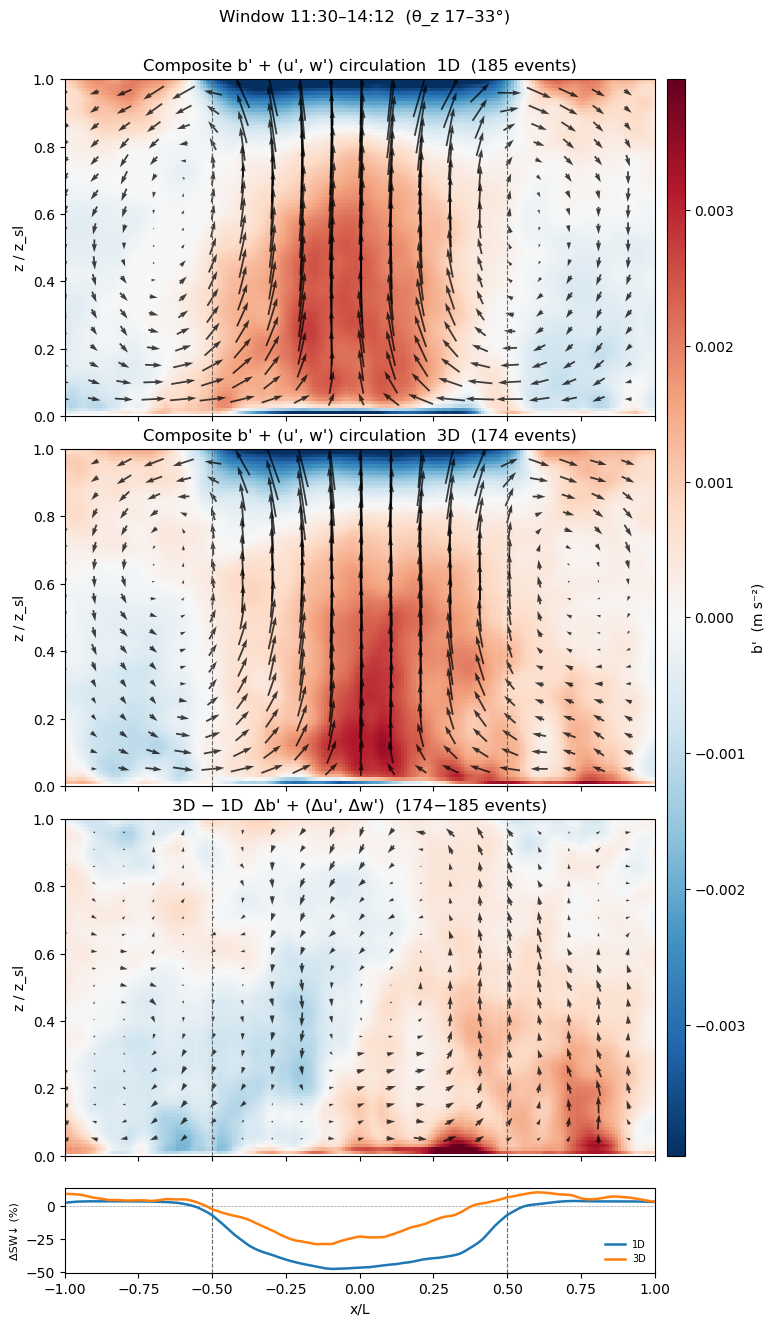

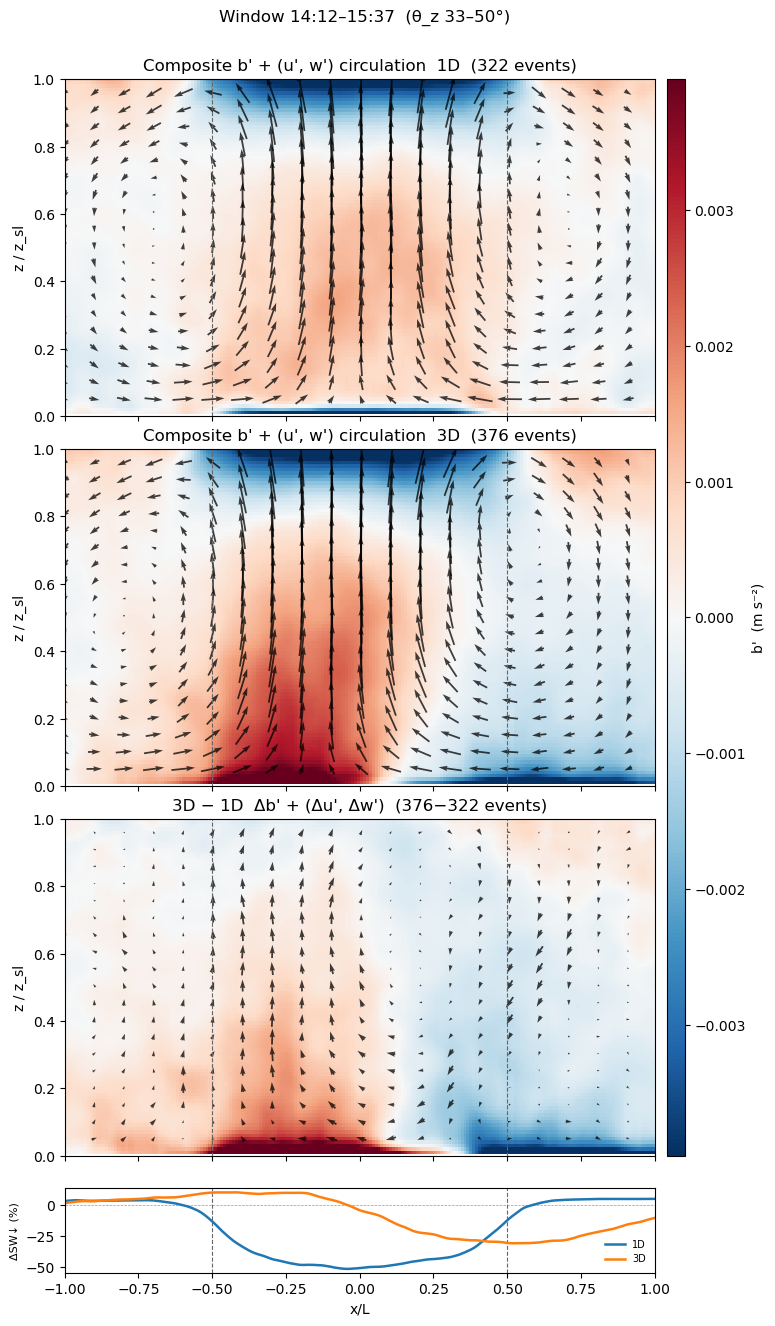

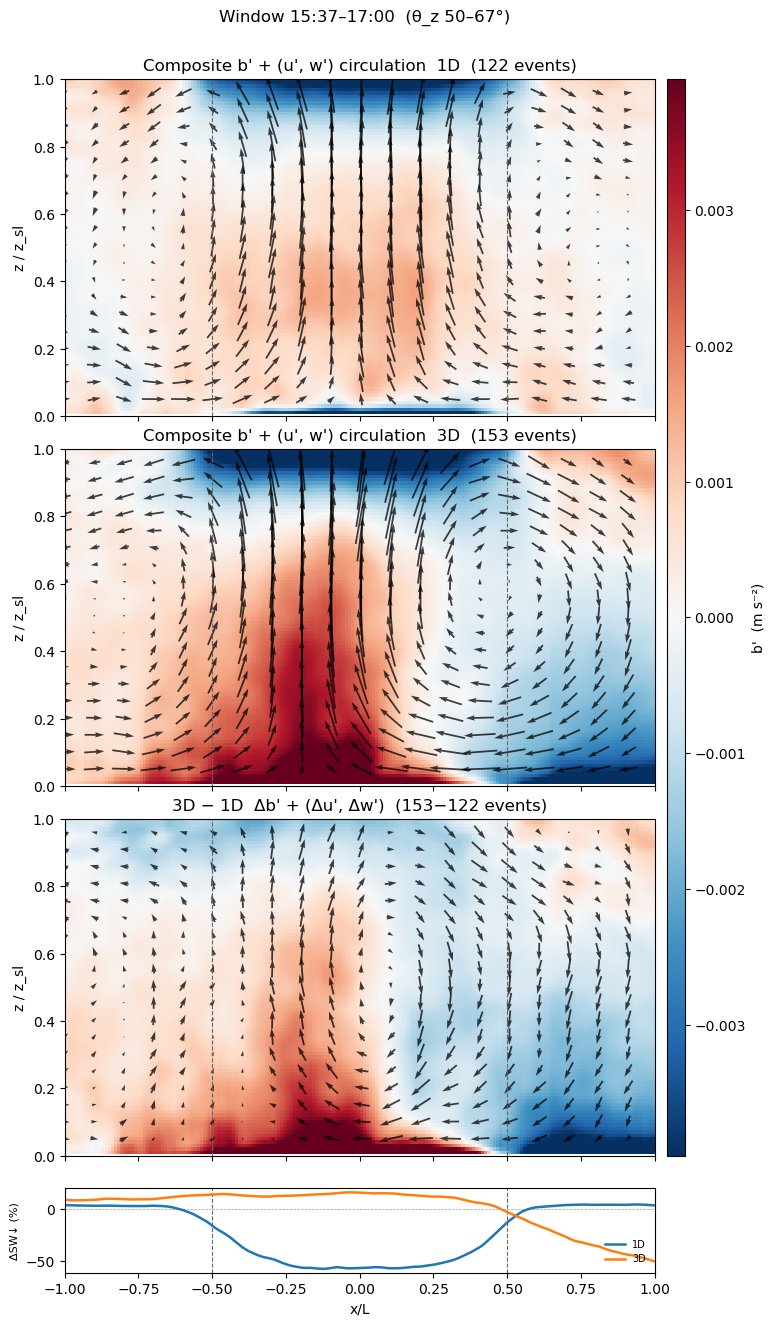

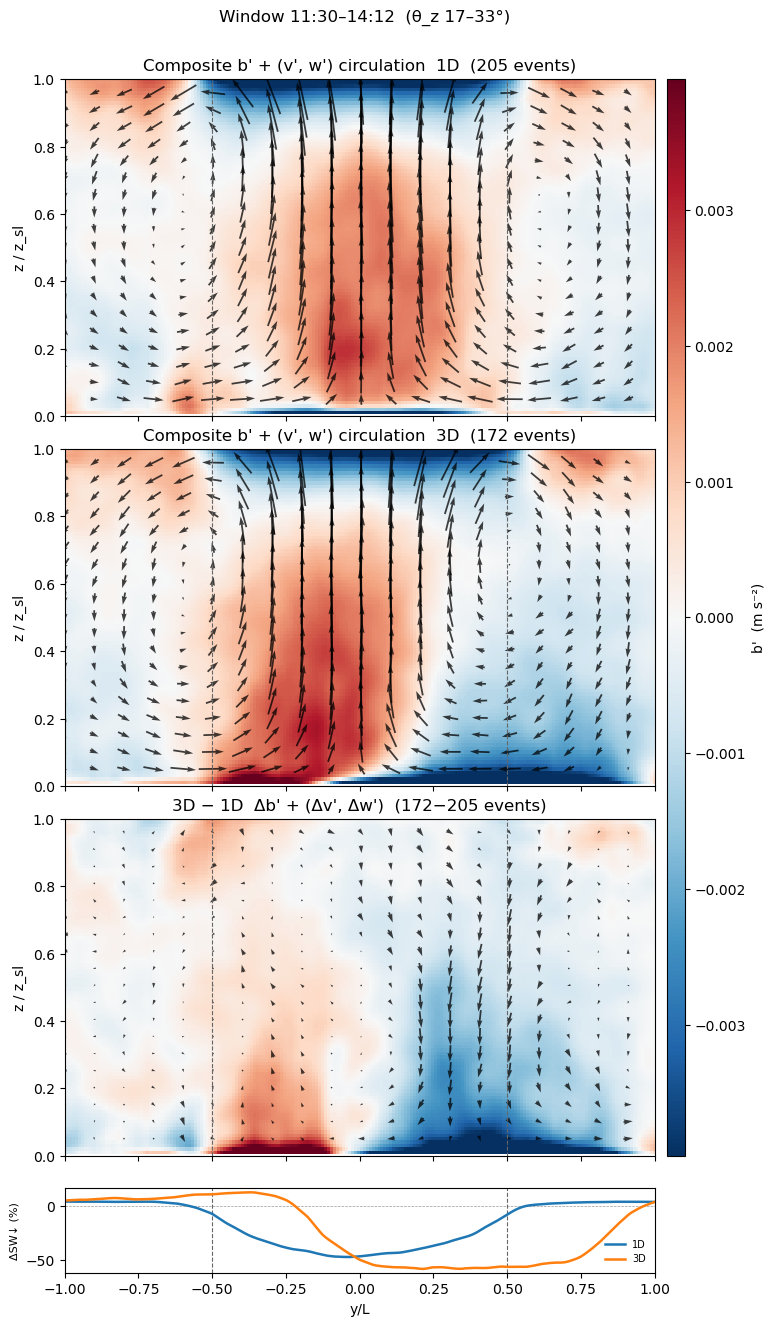

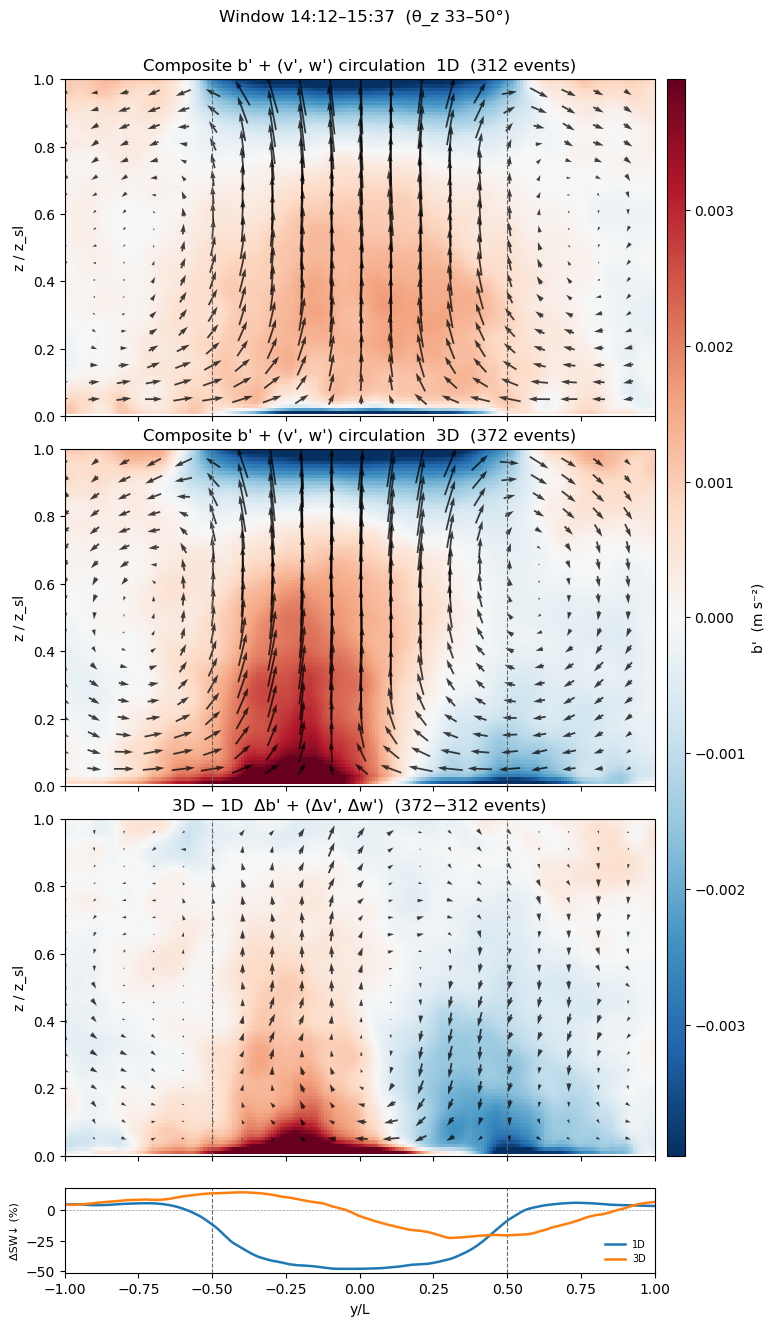

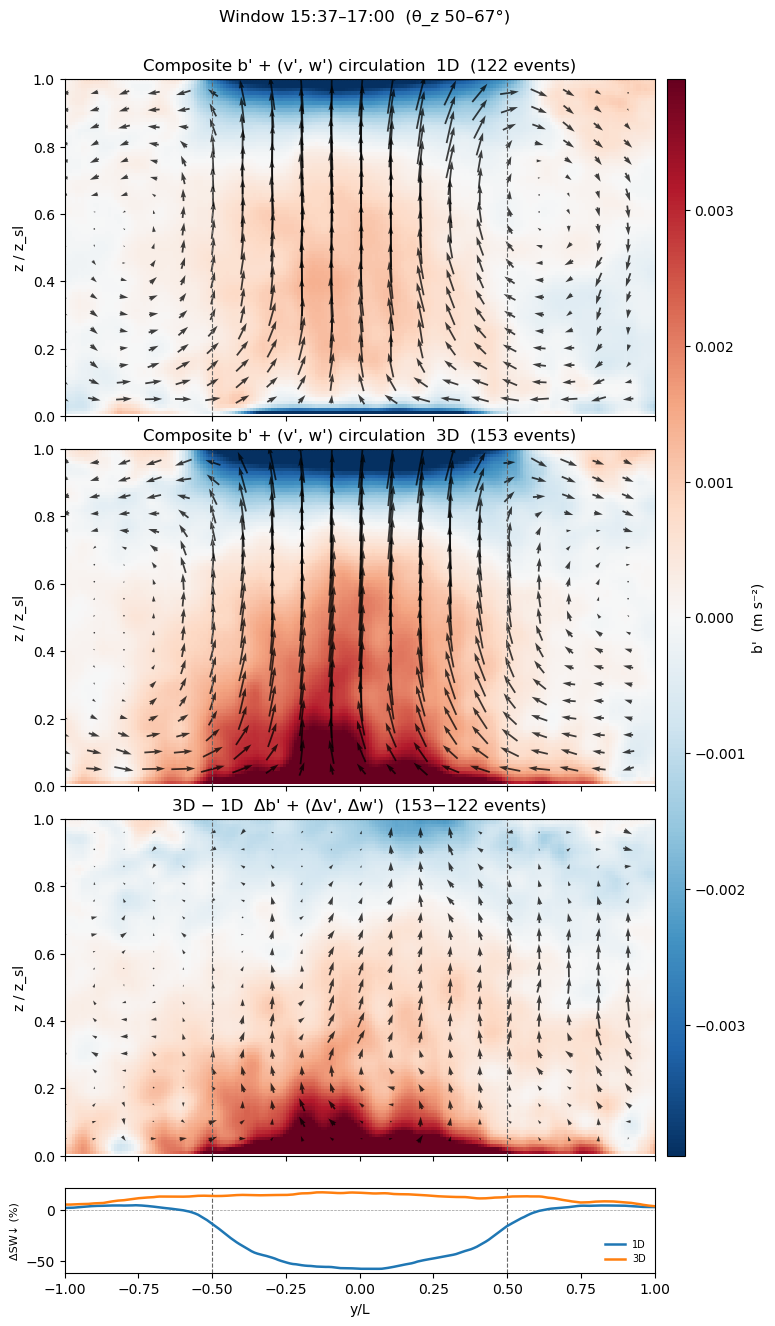

In [8]:
# Precompute shared colour + vector limits across ALL windows and orientations
_global_vlim_b, _global_qscale = _compute_global_limits(comp_windowed)
print(f'Global b\' limits: {_global_vlim_b[0]:.4f} to {_global_vlim_b[1]:.4f}')
print(f'Global quiver scale: {_global_qscale:.4f}')

_plot_shadow_figure_windowed('xz', vlim_b=_global_vlim_b, shared_qscale=_global_qscale)
_plot_shadow_figure_windowed('yz', vlim_b=_global_vlim_b, shared_qscale=_global_qscale)


## Azimuth-rotated composites

Same structure as the xz/yz windowed figures above, but the horizontal axis is
rotated into coordinates **parallel** and **perpendicular** to the solar azimuth.

For each SZA window the solar azimuth $\varphi$ (degrees from N, clockwise) is
computed at the window midpoint.  The parallel view combines the xz and yz
composites with weights $\sin^2\varphi$ (xz) and $\cos^2\varphi$ (yz),
and projects the horizontal wind: $u_{\parallel} = \sin\varphi\, u' + \cos\varphi\, v'$.
The perpendicular view uses the complementary weights.

**Convention**: $x$ = east, $y$ = north (MicroHH default).


In [18]:
def _plot_shadow_figure_azimuth(comp_az_data, vlim_b=None, shared_qscale=None):
    """Azimuth-rotated version of _plot_shadow_figure_windowed.

    Parameters
    ----------
    comp_az_data : dict  {case_key: {wi: {'parallel': ds, 'perpendicular': ds, ...}}}
    """
    n_win = len(SZA_WINDOWS)

    for wi in range(n_win):
        win_label = SZA_LABELS[wi]

        # Gather available panels
        avail_panels = []
        az_stats = None
        for case_key, case_label in [('1D', '1D'), ('3D', '3D')]:
            wi_data = comp_az_data.get(case_key, {}).get(wi, {})
            ds_par  = wi_data.get('parallel')
            ds_perp = wi_data.get('perpendicular')
            if ds_par is not None and ds_perp is not None:
                avail_panels.append((case_key, case_label, ds_par, ds_perp))
                if az_stats is None:
                    az_stats = wi_data.get('azimuth_stats')

        if not avail_panels:
            print(f'Window {wi} ({win_label}): no azimuth-rotated data — skipping.')
            continue

        has_diff = len(avail_panels) == 2

        # ── Figure layout: 2 columns (par, perp) + 1 thin cbar column ───
        n_circ = len(avail_panels) + (1 if has_diff else 0)
        n_rows = n_circ + 1   # + SW% panel
        h_ratios = [4] * n_circ + [1]

        fig = plt.figure(figsize=(15, 4.5 * n_circ + 2))
        gs = fig.add_gridspec(n_rows, 3,
                              width_ratios=[1, 1, 0.03],
                              height_ratios=h_ratios,
                              hspace=0.12, wspace=0.08)

        pcm_last = None  # save for shared colorbar

        for col_idx, direction in enumerate(['parallel', 'perpendicular']):
            c0 = col_idx  # 0 for parallel, 1 for perpendicular

            ax_circ = []
            for r in range(n_circ):
                ax = fig.add_subplot(gs[r, c0])
                ax_circ.append(ax)
                ax.tick_params(labelbottom=False)

            ax_sw = fig.add_subplot(gs[n_circ, c0], sharex=ax_circ[0])

            # ── Circulation panels ───────────────────────────────────────
            pcm = None
            for row, (key, label, ds_par, ds_perp) in enumerate(avail_panels):
                ds = ds_par if direction == 'parallel' else ds_perp
                pcm = plot_circulation_composite(
                    ax_circ[row], ds,
                    vlim_b=vlim_b,
                    label=label,
                    show_xlabel=False,
                    orient='xz',
                    show_colorbar=False,
                    quiver_scale=shared_qscale,
                )
                dir_sym = 'u_\u2225' if direction == 'parallel' else 'u_\u22a5'
                n_ev = '?'
                if 'n_events_per_rep' in ds:
                    n_ev = int(ds['n_events_per_rep'].values.sum())
                ax_circ[row].set_title(
                    f"{label}  b' + ({dir_sym}, w')  ({n_ev} events)")

            if pcm is not None:
                pcm_last = pcm

            # ── Difference panel ─────────────────────────────────────────
            if has_diff:
                ds_3d = avail_panels[1][2] if direction == 'parallel' else avail_panels[1][3]
                ds_1d = avail_panels[0][2] if direction == 'parallel' else avail_panels[0][3]
                diff_row = len(avail_panels)
                _plot_diff_circulation(
                    ax_circ[diff_row], ds_3d, ds_1d,
                    vlim_b=vlim_b, orient='xz',
                    show_xlabel=False,
                    quiver_scale=shared_qscale,
                )
                dir_sym = 'u_\u2225' if direction == 'parallel' else 'u_\u22a5'
                ax_circ[diff_row].set_title(
                    f"3D \u2212 1D  \u0394b' + (\u0394{dir_sym}, \u0394w')")

            # ── Axis labels ──────────────────────────────────────────────
            hl = 'r_\u2225 / L' if direction == 'parallel' else 'r_\u22a5 / L'
            for ax in ax_circ:
                ax.set_ylabel('z / z_sl' if col_idx == 0 else '')
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 1.0)
                if col_idx == 1:
                    ax.tick_params(labelleft=False)

            # ── SW % anomaly panel ───────────────────────────────────────
            ax_sw.axhline(0, color='0.6', lw=0.5, ls='--')
            ax_sw.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax_sw.axvline( 0.5, color='0.4', lw=0.8, ls='--')

            # SW blending uses mean azimuth for this window (already averaged)
            sw_plotted = False
            if az_stats is not None:
                az_mean = az_stats['mean']
                sp_mean = np.sin(np.radians(az_mean))
                cp_mean = np.cos(np.radians(az_mean))
                for key, label, _, _ in avail_panels:
                    sd = sw_data.get(key, {})
                    Q_blend = _blend_sw(sd, sp_mean, cp_mean, direction)
                    if Q_blend is not None and wi < Q_blend.shape[0]:
                        Q_win = Q_blend[wi]
                        Q_dm  = sd.get('Q_domain_mean')
                        if not np.all(np.isnan(Q_win)):
                            Q_ref = Q_dm[wi] if (Q_dm is not None and wi < len(Q_dm) and Q_dm[wi] > 0) else np.nanmean(Q_win)
                            Q_pct = 100.0 * (Q_win - Q_ref) / Q_ref
                            color = CASES[0]['color'] if key == '1D' else CASES[1]['color']
                            ax_sw.plot(_XL, Q_pct, color=color, lw=1.8, label=label)
                            sw_plotted = True

            if not sw_plotted:
                ax_sw.text(0.5, 0.5, 'no sw_composite data',
                           transform=ax_sw.transAxes, ha='center', va='center',
                           fontsize=8, color='gray')

            ax_sw.set_ylabel('\u0394SW\u2193 (%)' if col_idx == 0 else '', fontsize=8)
            ax_sw.set_xlim(-1, 1)
            ax_sw.set_xlabel(hl)
            ax_sw.legend(fontsize=7, frameon=False, loc='lower right')
            if col_idx == 1:
                ax_sw.tick_params(labelleft=False)

            # Column title
            ax_circ[0].text(0.5, 1.15, direction.capitalize(),
                            transform=ax_circ[0].transAxes,
                            ha='center', va='bottom', fontsize=12, fontweight='bold')

        # ── Shared colorbar on the far right ─────────────────────────────
        if pcm_last is not None:
            cbar_ax = fig.add_subplot(gs[:n_circ, 2])
            fig.colorbar(pcm_last, cax=cbar_ax, label="b'  (m s\u207b\u00b2)")

        # Suptitle with azimuth stats
        az_str = ''
        if az_stats is not None:
            az_str = (f'\n\u03c6_az = {az_stats["mean"]:.0f}\u00b0 \u00b1 {az_stats["std"]:.0f}\u00b0  '
                      f'(range {az_stats["min"]:.0f}\u2013{az_stats["max"]:.0f}\u00b0, '
                      f'n={az_stats["n"]} matched events)')

        plt.suptitle(
            f'Window {win_label}{az_str}',
            y=0.98, fontsize=11,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        if SAVE_PDF:
            fname = f'shadow_azimuth_win{wi}.pdf'
            plt.savefig(fname, bbox_inches='tight')
            print(f'Saved {fname}')
        plt.show()


1D (2stream):
  rep_01: 180 xz, 157 yz, 81 matched


/tmp/ipykernel_1614207/1644338109.py:137: RuntimeWarning: Mean of empty slice
  mean_vars[vn] = np.nanmean(stack, axis=0)


  rep_02: 149 xz, 171 yz, 74 matched


/tmp/ipykernel_1614207/1644338109.py:137: RuntimeWarning: Mean of empty slice
  mean_vars[vn] = np.nanmean(stack, axis=0)


  rep_03: 157 xz, 166 yz, 80 matched


...

/tmp/ipykernel_1614207/1644338109.py:137: RuntimeWarning: Mean of empty slice
  mean_vars[vn] = np.nanmean(stack, axis=0)


  rep_04: 191 xz, 176 yz, 104 matched


/tmp/ipykernel_1614207/1644338109.py:137: RuntimeWarning: Mean of empty slice
  mean_vars[vn] = np.nanmean(stack, axis=0)
/tmp/ipykernel_1614207/1644338109.py:174: RuntimeWarning: Mean of empty slice
  np.nanmean(stack, axis=0), dims=['z_nd', 'xL'])
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  1D win 0: az = 233.2 +/- 8.8 (range 204-236, n=75)
  1D win 1: az = 259.1 +/- 5.7 (range 253-265, n=162)
  1D win 2: az = 273.8 +/- 0.0 (range 274-274, n=62)
  3D win 0: az = 233.6 +/- 8.1 (range 204-236, n=59)
  3D win 1: az = 259.4 +/- 5.7 (range 253-265, n=228)
  3D win 2: az = 273.8 +/- 0.0 (range 274-274, n=102)


/tmp/ipykernel_1614207/2884926117.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


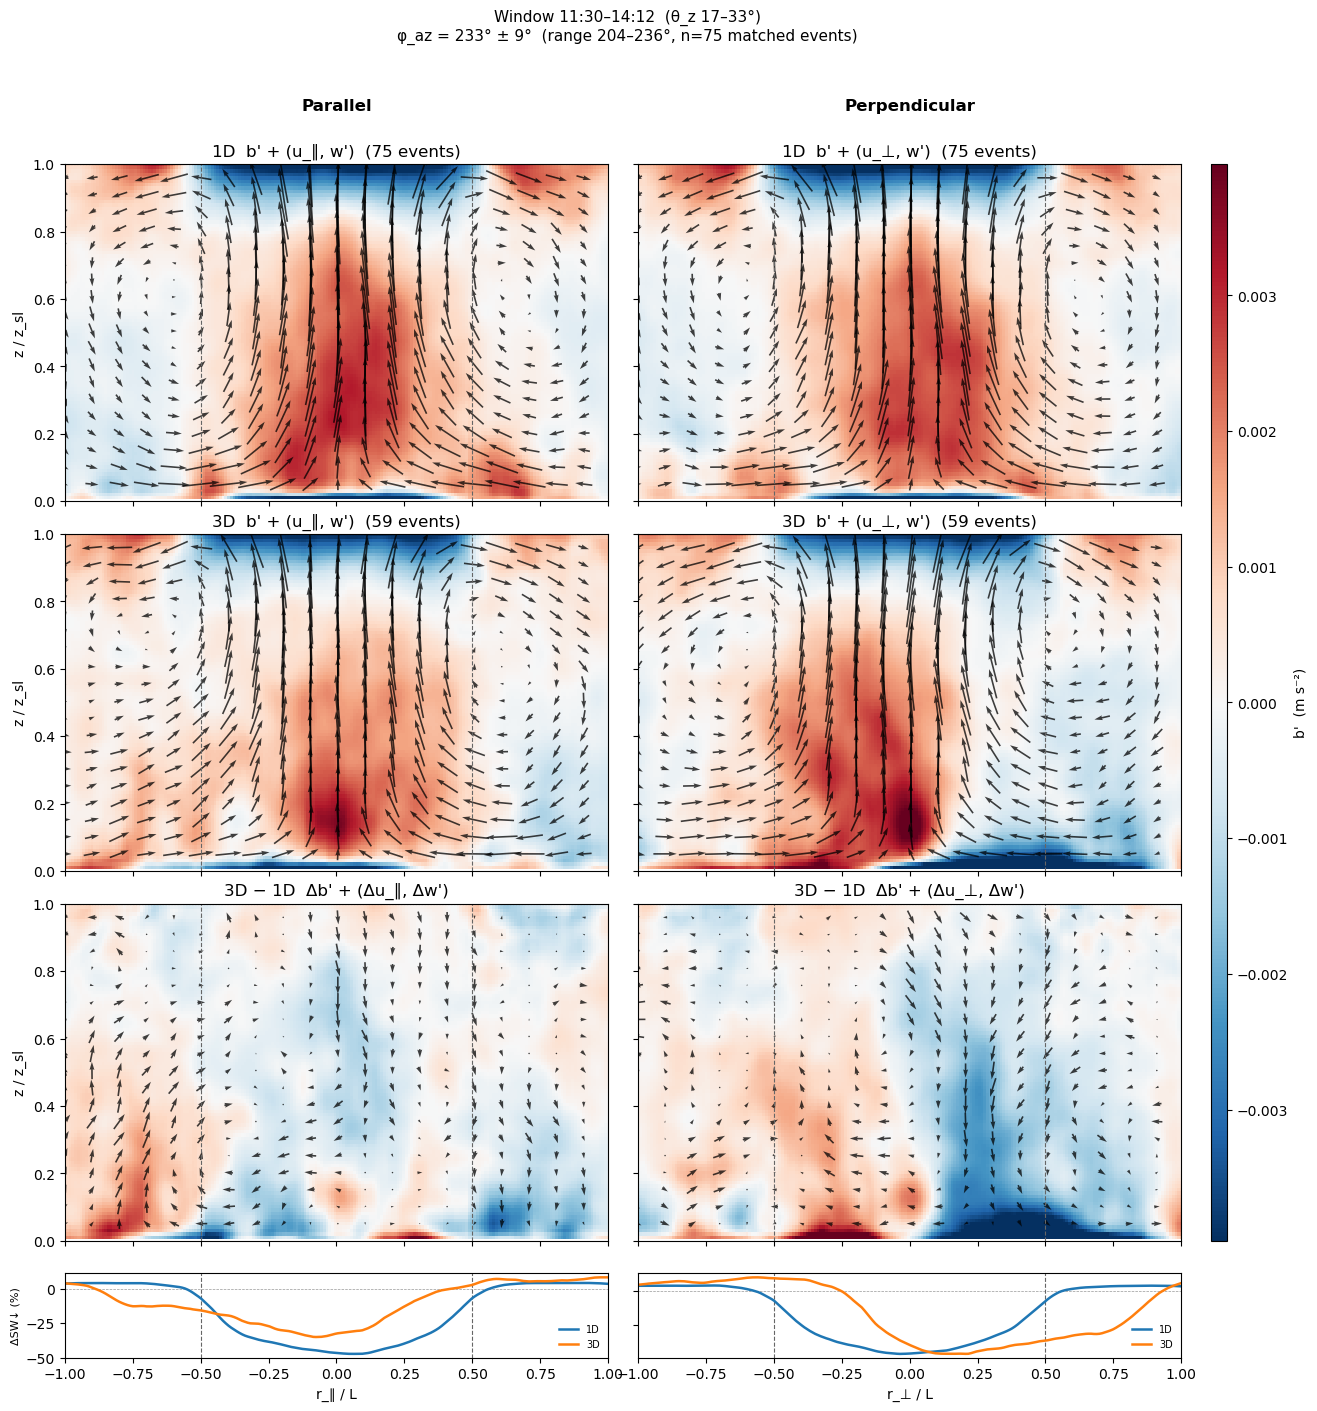

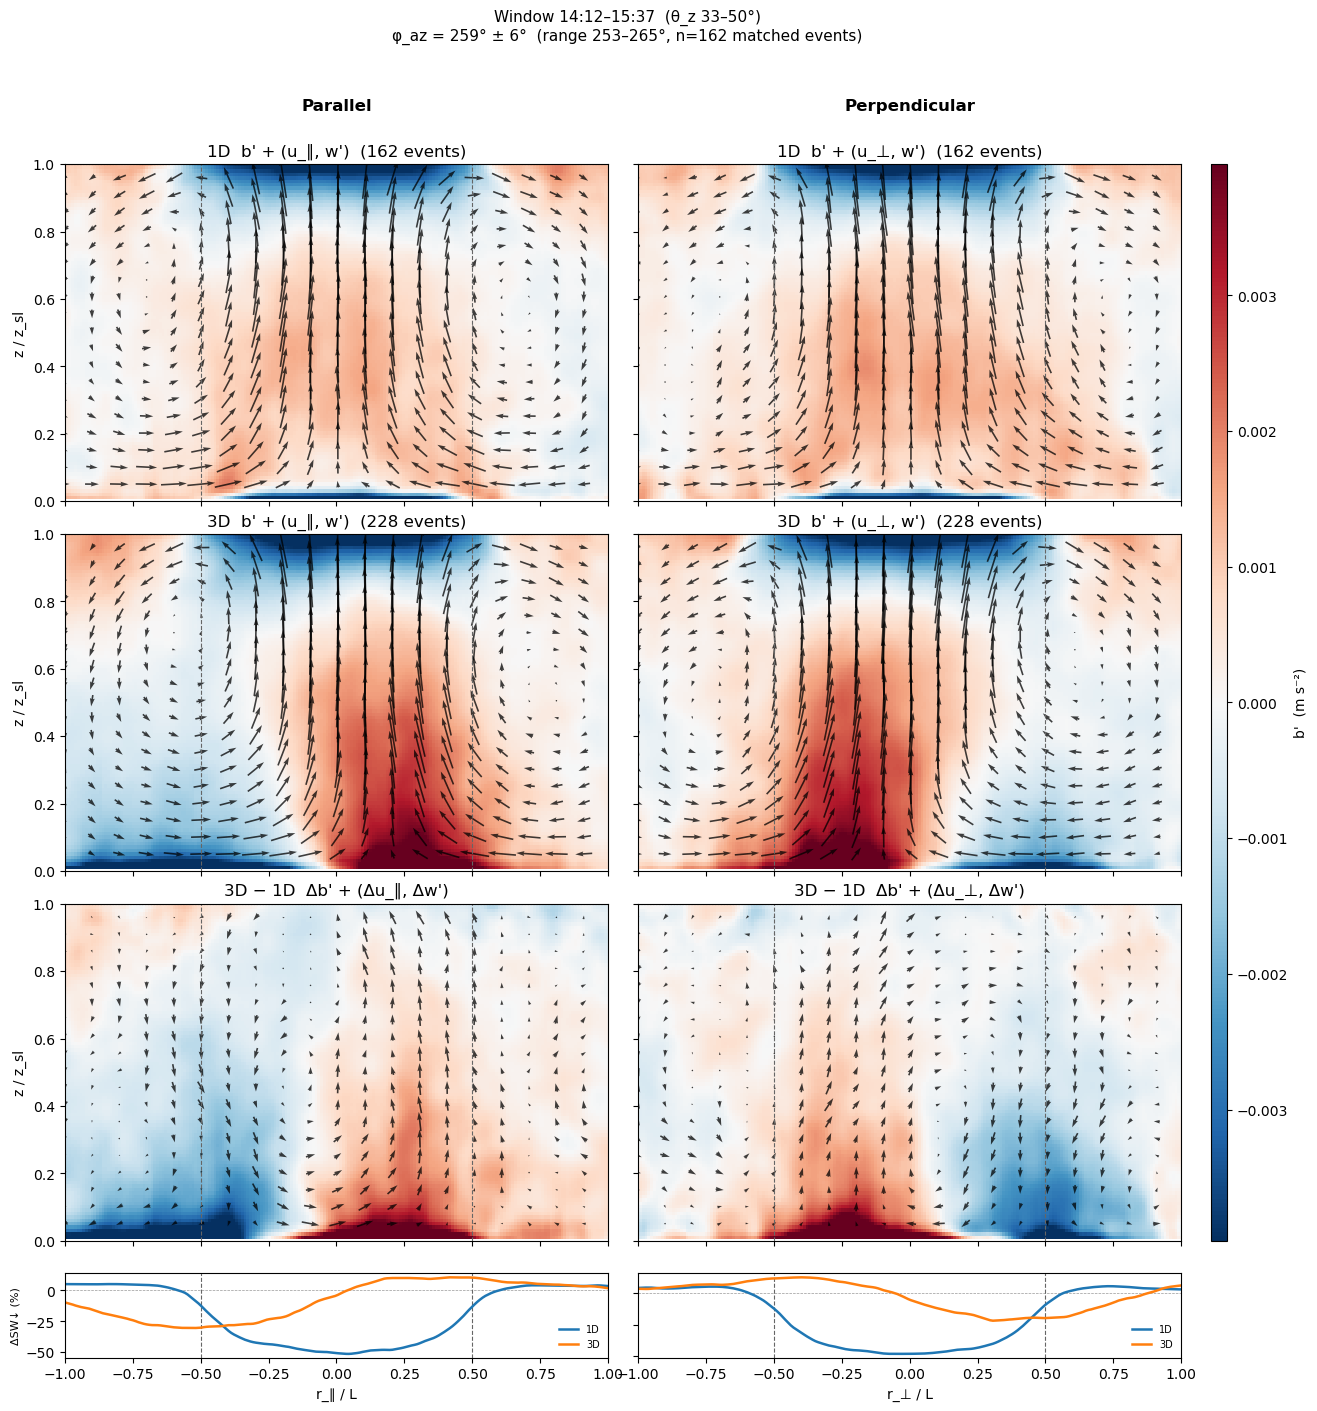

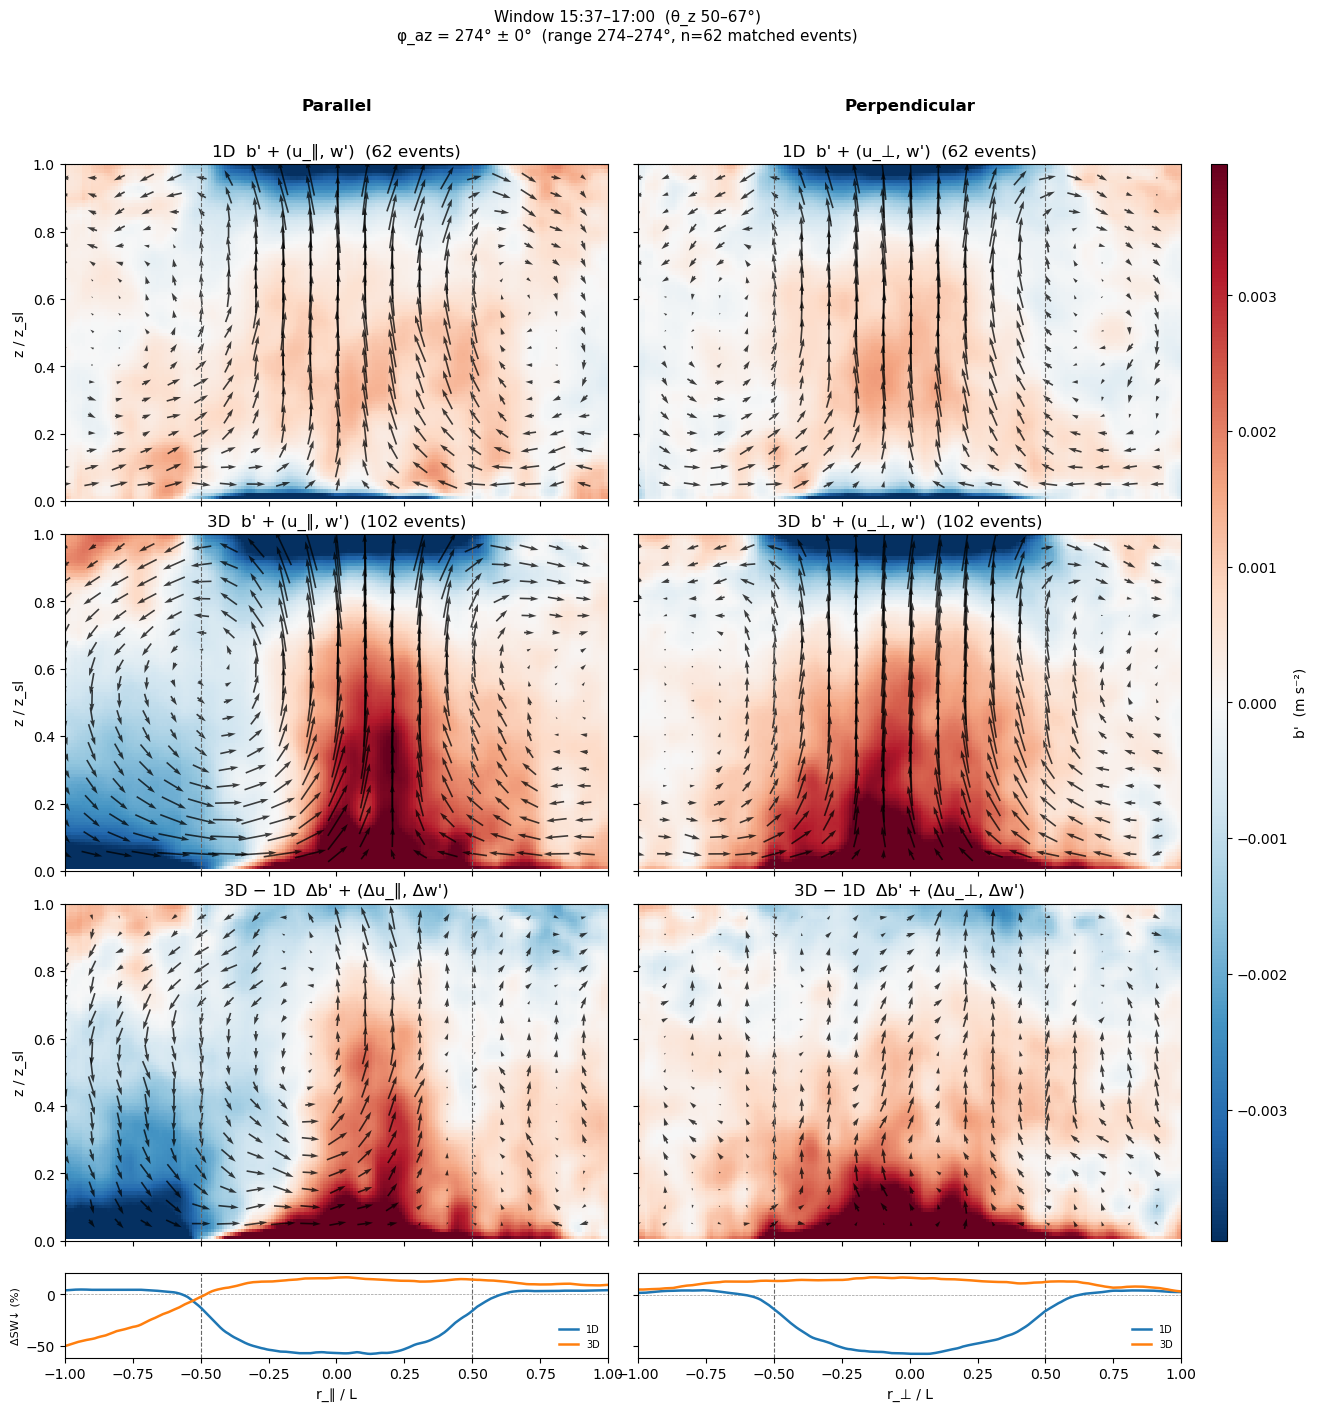

In [19]:
# ── Load azimuth-rotated composites (event-level blending) ────────────────────
comp_az_data = {}
for case in CASES:
    print(f'\n{case["label"]}:')
    comp_az_data[case['key']] = _average_reps_azimuth(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        windows=SZA_WINDOWS, window_labels=SZA_LABELS,
        n_reps=N_REPS, verbose=True,
    )

# Print azimuth stats
for case_key, wi_dict in comp_az_data.items():
    for wi, wi_data in wi_dict.items():
        az = wi_data.get('azimuth_stats')
        if az:
            print(f'  {case_key} win {wi}: az = {az["mean"]:.1f} +/- {az["std"]:.1f} '
                  f'(range {az["min"]:.0f}-{az["max"]:.0f}, n={az["n"]})')

_plot_shadow_figure_azimuth(comp_az_data, vlim_b=_global_vlim_b, shared_qscale=_global_qscale)


## Surface-field distributions: 1D vs 3D RT

Are 3D-RT clouds deeper / higher LWP because the feeding plumes are
**faster**, **moister**, or **warmer**?

Compare PDFs of near-surface perturbation fields (z = 12.5 m) and surface
fluxes, split by **all-domain** vs **cloud-root** (columns with LWP > 0).
Subcloud w' comes from hourly 3D dumps at z ≈ 500 m.


In [11]:
# ── Load surface-field distributions ──────────────────────────────────────────
from pathlib import Path
import gc

_LST_OFFSET = 5.5   # simulation t=0 → 05:30 LST
_LST_LO, _LST_HI = 11.5, 17.0
_LWP_THRESH = 1e-3  # kg m⁻² — column is "cloudy" if LWP > this

# ── Toggle: set False to skip 3D-dump fields (w', cloud-base θ_l/q_t) ────────
LOAD_3D = True

# Variables from xy files (z=12.5 m or surface)
_XY_VARS = {
    'thl':         dict(file='thl.xy.nc',         var='thl',         zdim='z',  label="θ_l'  (K)",             prime=True),
    'qt':          dict(file='qt.xy.nc',          var='qt',          zdim='z',  label="q_t' × 10³  (g kg⁻¹)",  prime=True, scale=1e3),
    'b':           dict(file='b.xy.nc',           var='b',           zdim='z',  label="b'  (m s⁻²)",           prime=True),
    'thl_fluxbot': dict(file='thl_fluxbot.xy.nc', var='thl_fluxbot', zdim=None, label="SHF  (K m s⁻¹)",        prime=False),
    'qt_fluxbot':  dict(file='qt_fluxbot.xy.nc',  var='qt_fluxbot',  zdim=None, label="LHF  (kg kg⁻¹ m s⁻¹)",  prime=False),
}

# w' from 3D dumps (hourly, z ≈ 500 m subcloud)
_W_Z_TARGET = 500.0   # m — subcloud level for w'

def _load_xy_distributions(run_dir, lwp_path=None):
    """Load surface xy fields, return dict of {varname: (all_vals, cloud_vals)}."""
    run_dir = Path(run_dir)
    result = {}

    # Time mask for LST window
    ds_ref = xr.open_dataset(run_dir / 'thl.xy.nc', decode_times=False)
    t_sec = ds_ref['time'].values
    lst = t_sec / 3600 + _LST_OFFSET
    tmask = (lst >= _LST_LO) & (lst <= _LST_HI)
    tidxs = np.where(tmask)[0]
    ds_ref.close()

    # Cloud mask from LWP
    ds_lwp = xr.open_dataset(run_dir / 'qlqi_path.xy.nc', decode_times=False)
    lwp_all = ds_lwp['qlqi_path'].values[tidxs]  # (nt, ny, nx)
    ds_lwp.close()
    cloud_mask = lwp_all > _LWP_THRESH  # (nt, ny, nx)

    for vname, spec in _XY_VARS.items():
        fpath = run_dir / spec['file']
        if not fpath.exists():
            print(f'  SKIP {fpath.name} (not found)')
            continue
        ds = xr.open_dataset(fpath, decode_times=False)
        arr = ds[spec['var']].values[tidxs]       # (nt, [1,] ny, nx)
        ds.close()
        if arr.ndim == 4:
            arr = arr[:, 0, :, :]                  # drop z/zh singleton

        scale = spec.get('scale', 1.0)
        if spec['prime']:
            # Subtract domain mean per timestep
            arr = arr - np.nanmean(arr, axis=(1, 2), keepdims=True)
        arr = arr * scale

        result[vname] = (arr.ravel(), arr[cloud_mask].ravel())

    # ── Cloud geometry: top, base, depth (cloudy columns only) ──────────────────
    ct_file = run_dir / 'qlqi_top.xy.nc'
    cb_file = run_dir / 'qlqi_base.xy.nc'
    if ct_file.exists() and cb_file.exists():
        ds_ct = xr.open_dataset(ct_file, decode_times=False)
        ds_cb = xr.open_dataset(cb_file, decode_times=False)
        ct_arr = ds_ct['qlqi_top'].values[tidxs]    # (nt, ny, nx) metres
        cb_arr = ds_cb['qlqi_base'].values[tidxs]
        ds_ct.close(); ds_cb.close()

        # Only meaningful for cloudy columns (cloud_mask already defined)
        ct_cloudy = ct_arr[cloud_mask]
        cb_cloudy = cb_arr[cloud_mask]
        depth_cloudy = ct_cloudy - cb_cloudy

        # "all domain" is meaningless (zeros for clear sky), store empty
        result['cloud_top']   = (np.array([]), ct_cloudy)
        result['cloud_base']  = (np.array([]), cb_cloudy)
        result['cloud_depth'] = (np.array([]), depth_cloudy)
    else:
        print('    SKIP cloud geometry (qlqi_top/base not found)')

        # ── SW↓ at surface ──────────────────────────────────────────────────────────
    try:
        sw_dn_full, _ = load_sfc_sw_dn(run_dir)
        sw_dn = sw_dn_full[tidxs]
        result['sw_dn'] = (sw_dn.ravel(), sw_dn[cloud_mask].ravel())
    except (FileNotFoundError, KeyError):
        print('    SKIP sw_dn (not found)')

    if LOAD_3D:
        # ── w' from 3D dumps ─────────────────────────────────────────────────────
        w_nc = run_dir / 'w.nc'
        if w_nc.exists():
            ds_w = xr.open_dataset(w_nc, decode_times=False)
            tw_sec = ds_w['time'].values
            tw_lst = tw_sec / 3600 + _LST_OFFSET
            tw_mask = (tw_lst >= _LST_LO) & (tw_lst <= _LST_HI)
            tw_idxs = np.where(tw_mask)[0]
    
            # Find nearest zh to target
            zh = ds_w['zh'].values
            zi = int(np.argmin(np.abs(zh - _W_Z_TARGET)))
            print(f'  w: using zh={zh[zi]:.0f} m (target {_W_Z_TARGET} m)')
    
            w_all_list, w_cld_list = [], []
            for ti in tw_idxs:
                w_slice = ds_w['w'].values[ti, zi, :, :]   # (ny, nx)
                w_prime = w_slice - np.nanmean(w_slice)
    
                # Cloud mask at nearest xy time
                sim_s = tw_sec[ti]
                xy_ti = int(np.argmin(np.abs(t_sec[tidxs] * 1.0 - sim_s)))
                cmask_t = cloud_mask[xy_ti]
    
                w_all_list.append(w_prime.ravel())
                w_cld_list.append(w_prime[cmask_t].ravel())
    
            ds_w.close()
            if w_all_list:
                result['w'] = (np.concatenate(w_all_list),
                               np.concatenate(w_cld_list))
        else:
            print(f'  SKIP w.nc (not found)')
    
        # ── θ_l and q_t at cloud base (from 3D dumps) ────────────────────────────
        thl_nc = run_dir / 'thl.nc'
        qt_nc  = run_dir / 'qt.nc'
        cb_nc  = run_dir / 'qlqi_base.xy.nc'
    
        if thl_nc.exists() and qt_nc.exists() and cb_nc.exists():
            ds_thl3d = xr.open_dataset(thl_nc, decode_times=False)
            ds_qt3d  = xr.open_dataset(qt_nc,  decode_times=False)
            ds_cb    = xr.open_dataset(cb_nc,  decode_times=False)
            z_full   = ds_thl3d['z'].values
            t3d_sec  = ds_thl3d['time'].values
            t3d_lst  = t3d_sec / 3600 + _LST_OFFSET
    
            # z-slab around typical cloud base
            _CB_Z_LO, _CB_Z_HI = 1100.0, 1800.0
            zmask = (z_full >= _CB_Z_LO) & (z_full <= _CB_Z_HI)
            z_slab = z_full[zmask]
    
            thl_cb_all, thl_cb_cld = [], []
            qt_cb_all,  qt_cb_cld  = [], []
            w_cb_all,   w_cb_cld   = [], []
    
            for ti in np.where((t3d_lst >= _LST_LO) & (t3d_lst <= _LST_HI))[0]:
                # Load z-slab for this timestep
                thl_slab = ds_thl3d['thl'].values[ti, zmask, :, :]   # (nz_slab, ny, nx)
                qt_slab  = ds_qt3d['qt'].values[ti, zmask, :, :]
    
                # Cloud base height at this time (nearest xy time)
                sim_s = t3d_sec[ti]
                cb_ti = int(np.argmin(np.abs(t_sec - sim_s)))
                cb_heights = ds_cb['qlqi_base'].values[cb_ti]   # (ny, nx) in metres
                cloudy_t = cb_heights > 0
    
                # For "all domain at cloud-base level": use fixed z near median CB
                zi_fix = int(np.argmin(np.abs(z_slab - 1388.0)))
                thl_fix = thl_slab[zi_fix]   # (ny, nx)
                qt_fix  = qt_slab[zi_fix]
    
                thl_fix_prime = thl_fix - np.nanmean(thl_fix)
                qt_fix_prime  = (qt_fix - np.nanmean(qt_fix)) * 1e3   # g/kg
    
                thl_cb_all.append(thl_fix_prime.ravel())
                qt_cb_all.append(qt_fix_prime.ravel())
    
                # For cloud-root: interpolate to actual per-column cloud-base height
                if cloudy_t.any():
                    cb_h = cb_heights[cloudy_t]            # (n_cloudy,)
                    rows, cols = np.where(cloudy_t)
    
                    # Vectorised linear interpolation along z_slab
                    # Find bracketing z-indices for each cloudy column
                    zi_lo = np.searchsorted(z_slab, cb_h) - 1
                    zi_lo = np.clip(zi_lo, 0, len(z_slab) - 2)
                    zi_hi = zi_lo + 1
                    dz = z_slab[zi_hi] - z_slab[zi_lo]
                    alpha = np.where(dz > 0, (cb_h - z_slab[zi_lo]) / dz, 0.0)
    
                    thl_lo = thl_slab[zi_lo, rows, cols]
                    thl_hi = thl_slab[zi_hi, rows, cols]
                    thl_interp = thl_lo + alpha * (thl_hi - thl_lo)
    
                    qt_lo = qt_slab[zi_lo, rows, cols]
                    qt_hi = qt_slab[zi_hi, rows, cols]
                    qt_interp = qt_lo + alpha * (qt_hi - qt_lo)
    
                    thl_interp_prime = thl_interp - np.nanmean(thl_fix)
                    qt_interp_prime  = (qt_interp - np.nanmean(qt_fix)) * 1e3
    
                    thl_cb_cld.append(thl_interp_prime)
                    qt_cb_cld.append(qt_interp_prime)
    
                # w at cloud base (from w.nc, zh levels)
                w_nc_path = run_dir / 'w.nc'
                if w_nc_path.exists():
                    ds_w3d = xr.open_dataset(w_nc_path, decode_times=False)
                    zh = ds_w3d['zh'].values
                    zh_mask = (zh >= _CB_Z_LO) & (zh <= _CB_Z_HI)
                    zh_slab = zh[zh_mask]
                    w_slab = ds_w3d['w'].values[ti, zh_mask, :, :]  # (nzh_slab, ny, nx)
                    ds_w3d.close()
    
                    # Fixed level
                    wi_fix = int(np.argmin(np.abs(zh_slab - 1388.0)))
                    w_fix = w_slab[wi_fix]
                    w_fix_prime = w_fix - np.nanmean(w_fix)
                    w_cb_all.append(w_fix_prime.ravel())
    
                    # Cloud-root: interpolate to actual CB height
                    if cloudy_t.any():
                        wi_lo = np.searchsorted(zh_slab, cb_h) - 1
                        wi_lo = np.clip(wi_lo, 0, len(zh_slab) - 2)
                        wi_hi = wi_lo + 1
                        dzh = zh_slab[wi_hi] - zh_slab[wi_lo]
                        alpha_w = np.where(dzh > 0, (cb_h - zh_slab[wi_lo]) / dzh, 0.0)
                        w_lo = w_slab[wi_lo, rows, cols]
                        w_hi = w_slab[wi_hi, rows, cols]
                        w_interp = w_lo + alpha_w * (w_hi - w_lo)
                        w_interp_prime = w_interp - np.nanmean(w_fix)
                        w_cb_cld.append(w_interp_prime)
    
            ds_thl3d.close()
            ds_qt3d.close()
            ds_cb.close()
    
            if thl_cb_all:
                result['thl_cb'] = (np.concatenate(thl_cb_all),
                                    np.concatenate(thl_cb_cld) if thl_cb_cld else np.array([]))
                result['qt_cb']  = (np.concatenate(qt_cb_all),
                                    np.concatenate(qt_cb_cld) if qt_cb_cld else np.array([]))
            if w_cb_all:
                result['w_cb']   = (np.concatenate(w_cb_all),
                                    np.concatenate(w_cb_cld) if w_cb_cld else np.array([]))
    
            print(f'    cloud-base sampling: {len(thl_cb_all)} dumps, '
                  f'{sum(len(x) for x in thl_cb_cld)} cloud-root values')
        else:
            missing = [f.name for f in [thl_nc, qt_nc, cb_nc] if not f.exists()]
            print(f'  SKIP cloud-base (missing: {missing})')
    
    else:
        print('    (skipping 3D fields — set LOAD_3D=True to enable)')
    gc.collect()
    return result


# ── Histogram bin definitions ─────────────────────────────────────────────────
# Pre-define bins so we can accumulate counts across reps without storing raw
# values.  Memory: ~200 bins * few vars * 2 RTs ≈ KB  (vs ~22 GB for raw).
_N_BINS = 200
_BIN_DEFS = {
    'thl':         np.linspace(-0.8, 0.8, _N_BINS + 1),
    'qt':          np.linspace(-0.8, 0.8, _N_BINS + 1),
    'b':           np.linspace(-0.03, 0.03, _N_BINS + 1),
    'thl_fluxbot': np.linspace(-0.02, 0.20, _N_BINS + 1),
    'qt_fluxbot':  np.linspace(-1e-5, 2.5e-4, _N_BINS + 1),
    'sw_dn':       np.linspace(0, 1100, _N_BINS + 1),
    'w':           np.linspace(-3.0, 5.0, _N_BINS + 1),
    'w_cb':        np.linspace(-3.0, 5.0, _N_BINS + 1),
    'thl_cb':      np.linspace(-1.5, 1.5, _N_BINS + 1),
    'qt_cb':       np.linspace(-1.5, 1.5, _N_BINS + 1),
    'cloud_top':   np.linspace(1000, 3500, _N_BINS + 1),
    'cloud_base':  np.linspace(1000, 2500, _N_BINS + 1),
    'cloud_depth': np.linspace(0, 1500, _N_BINS + 1),
}

# ── Accumulate histograms across reps (with pickle cache) ─────────────────────
# dist_data[rt_key][varname] = {all_counts, cloud_counts, edges, all_n, ...}
import pickle as _pkl

_cache_tag = f'{"3d" if LOAD_3D else "xy"}_{EXPT_KEY}'
_cache_path = Path(f'.dist_cache_{_cache_tag}.pkl')

def _compute_dist_data():
    dist_data = {}
    for case in CASES:
        key = case['key']
        print(f'\n{case["label"]}:')
        accum = {}

        for rep in range(1, N_REPS + 1):
            run_dir = Path(case['run_root']) / f'rep_{rep:02d}'
            if not run_dir.exists():
                print(f'  rep_{rep:02d}: MISSING')
                continue
            print(f'  rep_{rep:02d}:')
            rep_data = _load_xy_distributions(run_dir)

            for vname, (a_vals, c_vals) in rep_data.items():
                if vname not in _BIN_DEFS:
                    lo = np.nanpercentile(a_vals, 0.5)
                    hi = np.nanpercentile(a_vals, 99.5)
                    if len(c_vals) > 0:
                        lo = min(lo, np.nanpercentile(c_vals, 0.5))
                        hi = max(hi, np.nanpercentile(c_vals, 99.5))
                    _BIN_DEFS[vname] = np.linspace(lo, hi, _N_BINS + 1)

                edges = _BIN_DEFS[vname]

                if vname not in accum:
                    accum[vname] = dict(
                        all_counts   = np.zeros(_N_BINS, dtype=np.int64),
                        cloud_counts = np.zeros(_N_BINS, dtype=np.int64),
                        edges        = edges,
                        all_n = 0, cloud_n = 0,
                        all_sum = 0.0, cloud_sum = 0.0,
                    )

                h_all, _ = np.histogram(a_vals, bins=edges)
                accum[vname]['all_counts'] += h_all
                accum[vname]['all_n']      += len(a_vals)
                accum[vname]['all_sum']    += np.nansum(a_vals.astype(np.float64))

                if len(c_vals) > 0:
                    h_cld, _ = np.histogram(c_vals, bins=edges)
                    accum[vname]['cloud_counts'] += h_cld
                    accum[vname]['cloud_n']      += len(c_vals)
                    accum[vname]['cloud_sum']    += np.nansum(c_vals.astype(np.float64))

            del rep_data
            gc.collect()

        dist_data[key] = accum
        for vname, d in accum.items():
            print(f'  {vname}: {d["all_n"]:,} all, {d["cloud_n"]:,} cloud-root')

    return dist_data


if _cache_path.exists():
    with open(_cache_path, 'rb') as _f:
        dist_data = _pkl.load(_f)
    print(f'Loaded cached histograms from {_cache_path}')
    for key, accum in dist_data.items():
        for vname, d in accum.items():
            print(f'  {key}/{vname}: {d["all_n"]:,} all, {d["cloud_n"]:,} cloud-root')
else:
    dist_data = _compute_dist_data()
    with open(_cache_path, 'wb') as _f:
        _pkl.dump(dist_data, _f)
    print(f'\nCached histograms to {_cache_path}')


Loaded cached histograms from .dist_cache_3d_no_aerosols_zero_wind.pkl
  1D/thl: 347,078,656 all, 45,773,481 cloud-root
  1D/qt: 347,078,656 all, 45,773,481 cloud-root
  1D/b: 347,078,656 all, 45,773,481 cloud-root
  1D/thl_fluxbot: 347,078,656 all, 45,773,481 cloud-root
  1D/qt_fluxbot: 347,078,656 all, 45,773,481 cloud-root
  1D/cloud_top: 0 all, 45,773,481 cloud-root
  1D/cloud_base: 0 all, 45,773,481 cloud-root
  1D/cloud_depth: 0 all, 45,773,481 cloud-root
  1D/sw_dn: 347,078,656 all, 45,773,481 cloud-root
  1D/sw_dn_prime: 347,078,656 all, 45,773,481 cloud-root
  1D/w: 6,291,456 all, 744,296 cloud-root
  1D/thl_cb: 6,291,456 all, 816,973 cloud-root
  1D/qt_cb: 6,291,456 all, 816,973 cloud-root
  1D/w_cb: 6,291,456 all, 816,973 cloud-root
  3D/thl: 347,078,656 all, 47,963,072 cloud-root
  3D/qt: 347,078,656 all, 47,963,072 cloud-root
  3D/b: 347,078,656 all, 47,963,072 cloud-root
  3D/thl_fluxbot: 347,078,656 all, 47,963,072 cloud-root
  3D/qt_fluxbot: 347,078,656 all, 47,963,072 

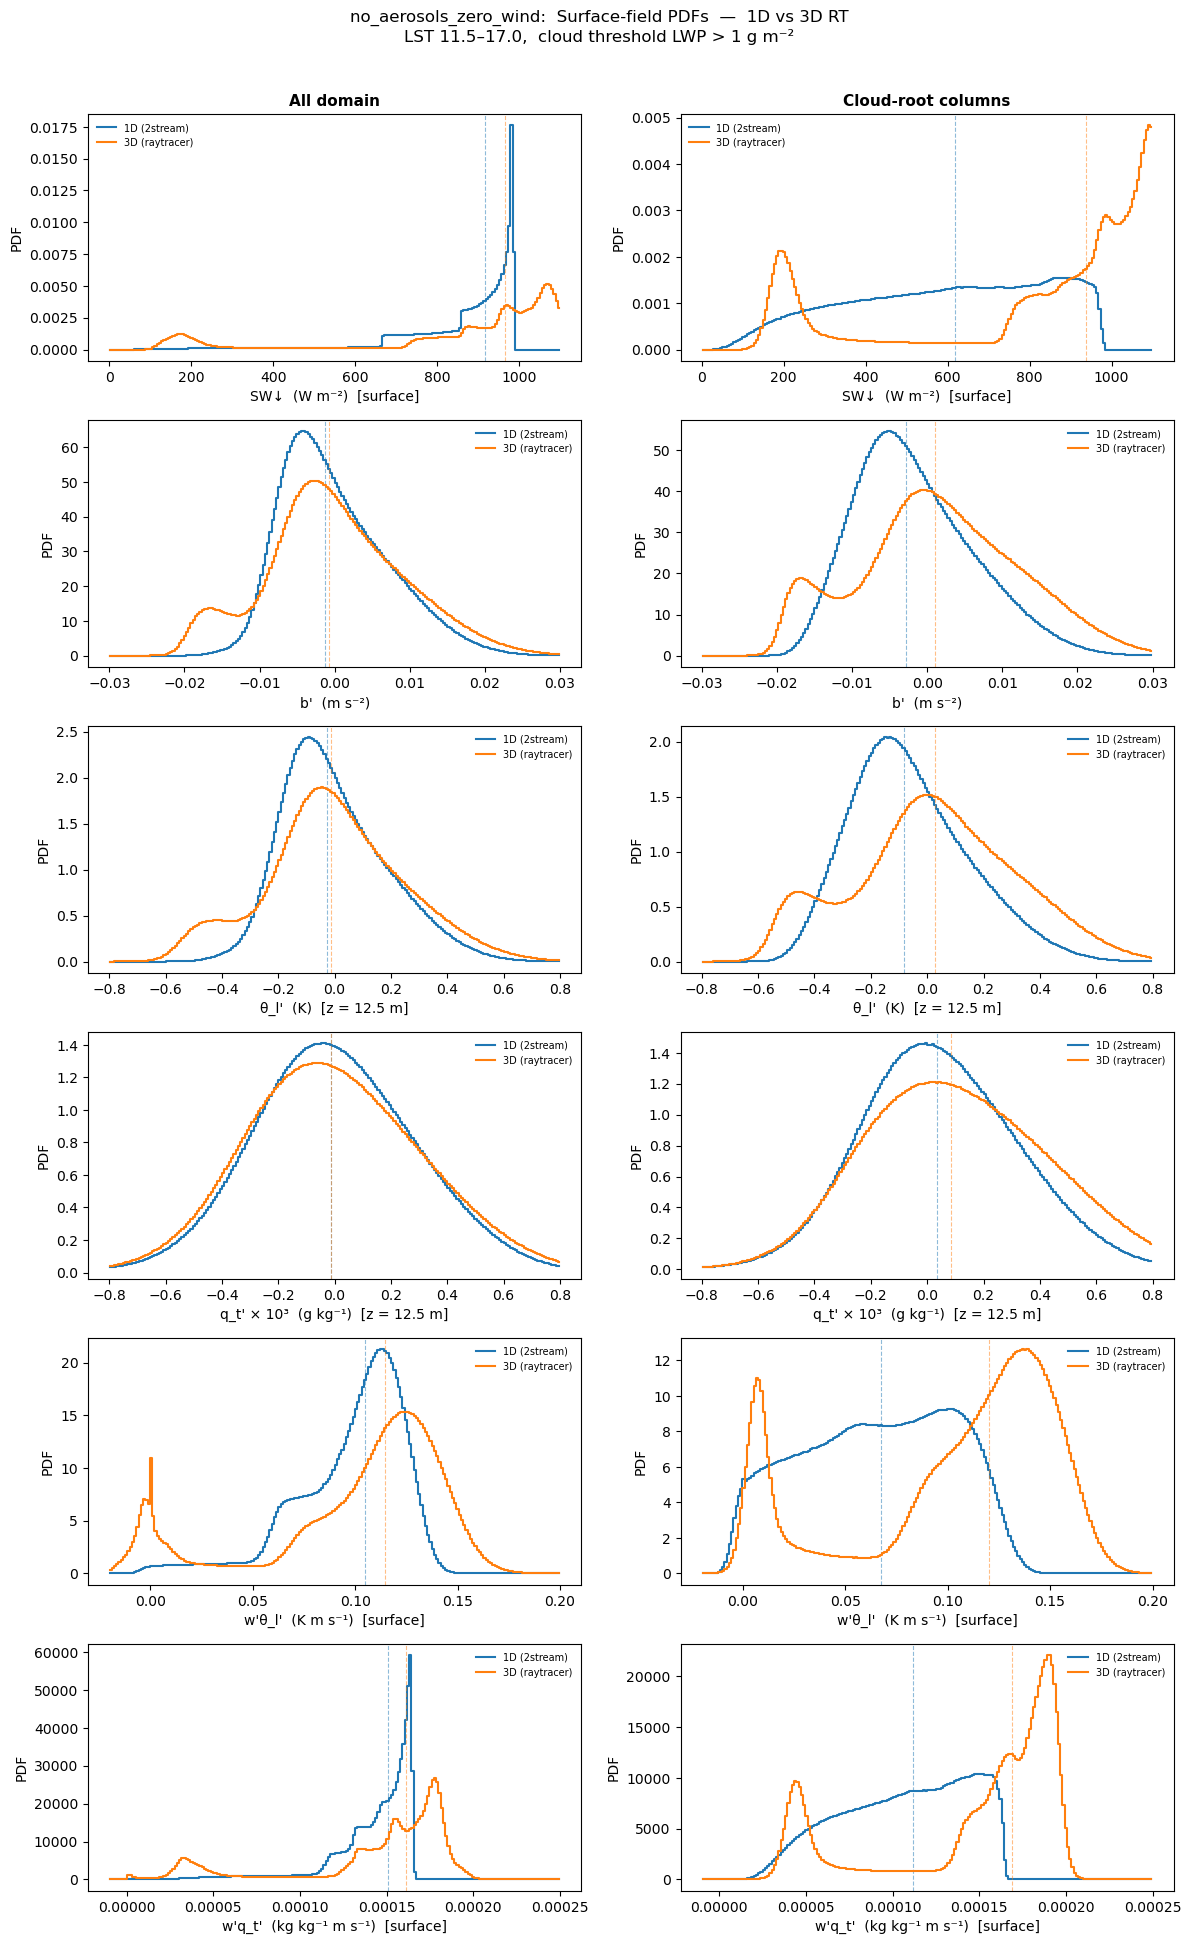

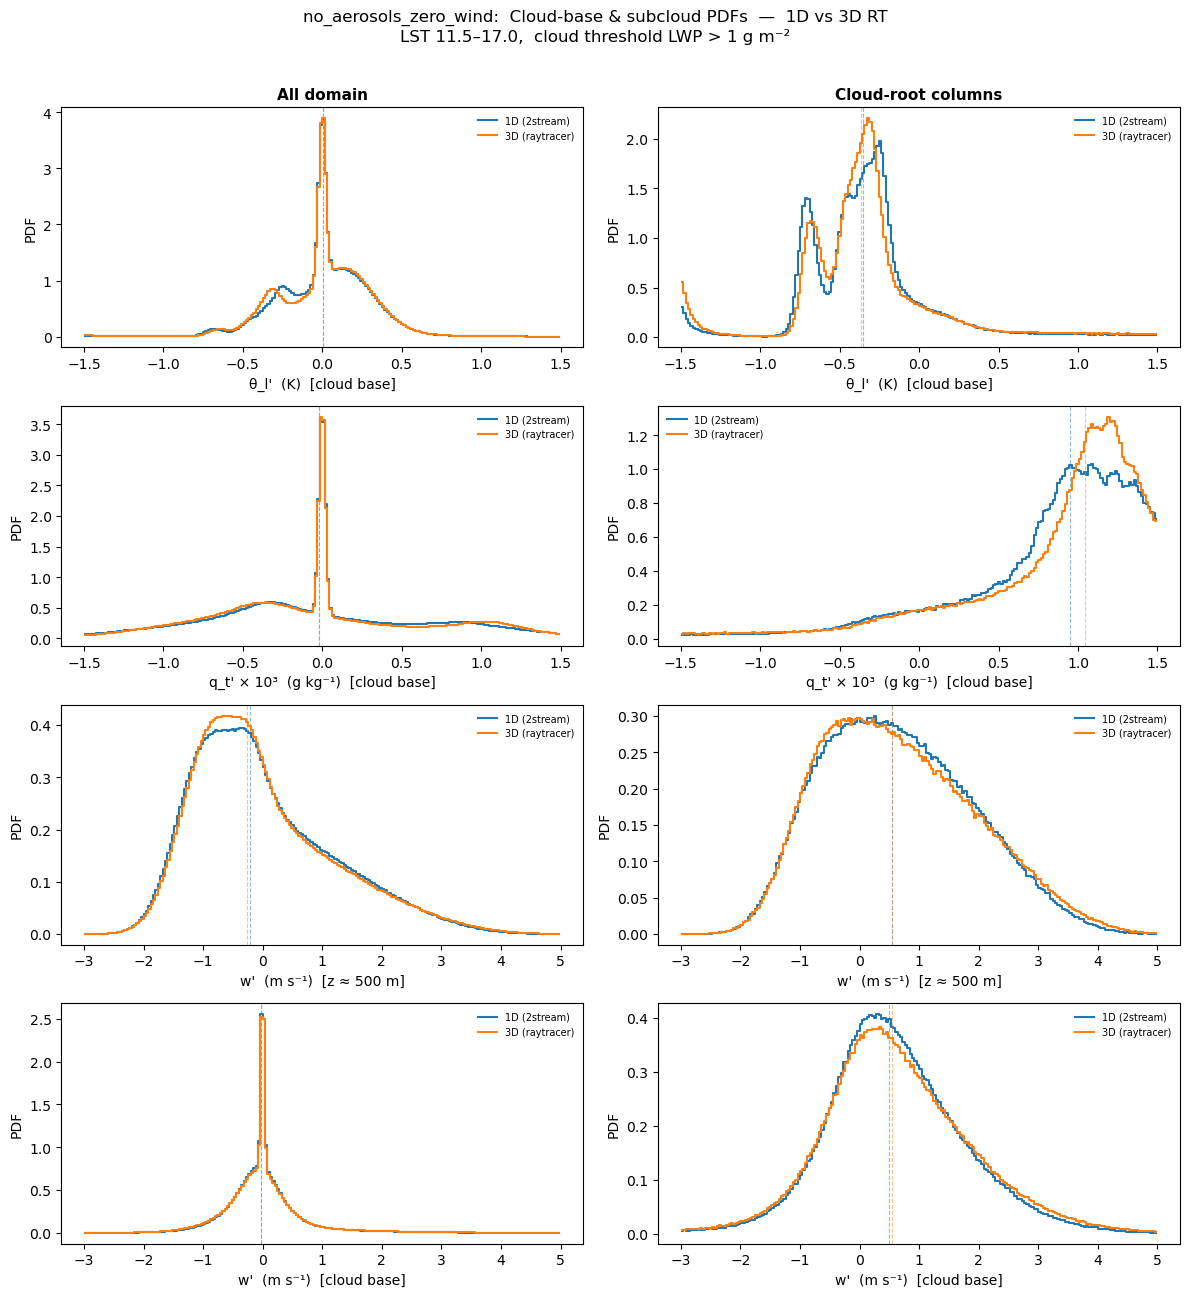


Variable         Subset              1D mean      3D mean     Δ(3D-1D)   Δ/|1D|%      1D med     3D med
───────────────────────────────────────────────────────────────────────────────────────────────────────
sw_dn            all              859.924436   869.098237    +9.173801     +1.1%  915.750000 965.250000
sw_dn            cloud-root       596.855216   840.417947  +243.562731    +40.8%  618.750000 937.750000
b                all                0.000000     0.000000    +0.000000     +nan%   -0.001350  -0.000750
b                cloud-root        -0.001692     0.001520    +0.003212   +189.8%   -0.002850   0.001050
thl              all                0.000000    -0.000000    -0.000000     +nan%   -0.028000  -0.012000
thl              cloud-root        -0.061501     0.026922    +0.088423   +143.8%   -0.084000   0.028000
qt               all               -0.000000     0.000000    +0.000000     +nan%   -0.012000  -0.012000
qt               cloud-root         0.048023     0.110659    +0

In [17]:
# ── Plot distributions (from pre-binned histograms) ──────────────────────────
_SURFACE_VARS = ['sw_dn', 'b', 'thl', 'qt', 'thl_fluxbot', 'qt_fluxbot']
_UPPER_VARS   = ['thl_cb', 'qt_cb', 'w', 'w_cb']
# , 'cloud_top', 'cloud_base', 'cloud_depth'
_PLOT_LABELS = {
    'w':           "w'  (m s⁻¹)  [z ≈ 500 m]",
    'w_cb':        "w'  (m s⁻¹)  [cloud base]",
    'b':           "b'  (m s⁻²)",
    'thl':         "θ_l'  (K)  [z = 12.5 m]",
    'thl_cb':      "θ_l'  (K)  [cloud base]",
    'qt':          "q_t' × 10³  (g kg⁻¹)  [z = 12.5 m]",
    'qt_cb':       "q_t' × 10³  (g kg⁻¹)  [cloud base]",
    'thl_fluxbot': "w'θ_l'  (K m s⁻¹)  [surface]",
    'qt_fluxbot':  "w'q_t'  (kg kg⁻¹ m s⁻¹)  [surface]",
    'sw_dn':       "SW↓  (W m⁻²)  [surface]",
    # 'cloud_top':   "cloud top  (m)",
    # 'cloud_base':  "cloud base  (m)",
    # 'cloud_depth': "cloud depth  (m)",
}


def _counts_to_pdf(counts, edges):
    dx = edges[1] - edges[0]
    total = counts.sum()
    if total == 0:
        return np.zeros_like(counts, dtype=float)
    return counts.astype(float) / (total * dx)


def _hist_median(counts, edges):
    cdf = np.cumsum(counts).astype(float)
    if cdf[-1] == 0:
        return np.nan
    cdf /= cdf[-1]
    centres = 0.5 * (edges[:-1] + edges[1:])
    idx = np.searchsorted(cdf, 0.5)
    return float(centres[min(idx, len(centres) - 1)])


def _plot_dist_figure(var_list, title_suffix):
    avail = [v for v in var_list if any(v in dist_data[k] for k in dist_data)]
    if not avail:
        print(f'No variables available for "{title_suffix}" — skipping.')
        return

    n_vars = len(avail)
    fig, axes = plt.subplots(n_vars, 2, figsize=(12, 3.2 * n_vars), sharex='row')
    if n_vars == 1:
        axes = axes[np.newaxis, :]

    for row, vname in enumerate(avail):
        for col, (subset_label, ck, nk, sk) in enumerate([
            ('All domain',         'all_counts',   'all_n',   'all_sum'),
            ('Cloud-root columns', 'cloud_counts', 'cloud_n', 'cloud_sum'),
        ]):
            ax = axes[row, col]
            for case in CASES:
                key = case['key']
                if vname not in dist_data[key]:
                    continue
                d = dist_data[key][vname]
                counts = d[ck]
                edges  = d['edges']
                if d[nk] == 0:
                    continue

                pdf = _counts_to_pdf(counts, edges)
                centres = 0.5 * (edges[:-1] + edges[1:])
                ax.step(centres, pdf, where='mid',
                        color=case['color'], lw=1.5, label=case['label'])

                med = _hist_median(counts, edges)
                ax.axvline(med, color=case['color'], ls='--', lw=0.8, alpha=0.5)

            ax.set_ylabel('PDF')
            if row == 0:
                ax.set_title(subset_label, fontsize=11, fontweight='bold')
            ax.legend(fontsize=7, frameon=False)
            ax.set_xlabel(_PLOT_LABELS.get(vname, vname))

    fig.suptitle(
        f'{EXPT_KEY}:  {title_suffix}  —  1D vs 3D RT\n'
        f'LST {_LST_LO:.1f}–{_LST_HI:.1f},  cloud threshold LWP > {_LWP_THRESH*1e3:.0f} g m⁻²',
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    if SAVE_PDF:
        tag = title_suffix.lower().replace(' ', '_')
        plt.savefig(f'dist_{tag}.pdf', bbox_inches='tight')
        print(f'Saved dist_{tag}.pdf')
    plt.show()
    return avail


# ── Figure 1: surface / near-surface fields ──────────────────────────────────
sfc_avail = _plot_dist_figure(_SURFACE_VARS, 'Surface-field PDFs')

# ── Figure 2: cloud-base and subcloud fields ─────────────────────────────────
upper_avail = _plot_dist_figure(_UPPER_VARS, 'Cloud-base & subcloud PDFs')

# ── Summary table ────────────────────────────────────────────────────────────
_all_avail = (sfc_avail or []) + (upper_avail or [])
hdr = f'{"Variable":<16} {"Subset":<14} {"1D mean":>12} {"3D mean":>12} {"Δ(3D-1D)":>12} {"Δ/|1D|%":>9}  {"1D med":>10} {"3D med":>10}'
print(f'\n{hdr}')
print('─' * len(hdr))
for vname in _all_avail:
    for subset_label, ck, nk, sk in [
        ('all',        'all_counts',   'all_n',   'all_sum'),
        ('cloud-root', 'cloud_counts', 'cloud_n', 'cloud_sum'),
    ]:
        d1 = dist_data.get('1D', {}).get(vname)
        d3 = dist_data.get('3D', {}).get(vname)
        if d1 is None or d3 is None or d1[nk] == 0 or d3[nk] == 0:
            continue
        mu1  = d1[sk] / d1[nk]
        mu3  = d3[sk] / d3[nk]
        med1 = _hist_median(d1[ck], d1['edges'])
        med3 = _hist_median(d3[ck], d3['edges'])
        delta = mu3 - mu1
        pct   = 100 * delta / abs(mu1) if abs(mu1) > 1e-15 else float('nan')
        print(f'{vname:<16} {subset_label:<14} {mu1:>12.6f} {mu3:>12.6f} {delta:>+12.6f} {pct:>+8.1f}%  {med1:>10.6f} {med3:>10.6f}')

In [4]:
import numpy as np
import matplotlib.pyplot as plt

w_star = 2

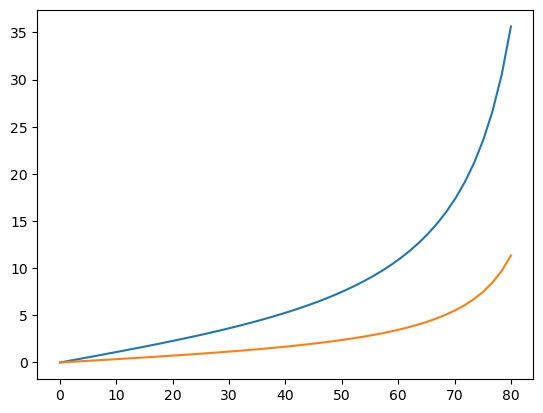

In [7]:
theta = np.deg2rad(np.linspace(0, 80))
plt.plot(np.linspace(0, 80), w_star*np.pi*np.tan(theta))
plt.plot(np.linspace(0, 80), w_star*np.tan(theta))